In [7]:
# import sys
# sys.path.insert(0, '/home/stargix/Desktop/uni/aprens/Lab8/APRNS-Lab-8/pytorch-generative')

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import optim
from torch.utils.data import Dataset, DataLoader
from torch.nn import functional as F
from torch.optim import lr_scheduler
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from apafib import load_MITBIH
import sys
from pytorch_generative import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [9]:
data = load_MITBIH()
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

X_normal = X[y == 'Normal'] 

padding = np.zeros((X_normal.shape[0], 2))
X_padded = np.hstack((X_normal, padding))

print(f"Shape original: {X_normal.shape}, Shape con padding: {X_padded.shape}")

X_discretization, X_autoreg = train_test_split(X_padded, test_size=0.66, random_state=42)

Shape original: (7263, 94), Shape con padding: (7263, 96)


In [10]:
# Funciones para discretización y reconstrucción
def discretize_signals(signals, window_size, model):
    n_samples, length = signals.shape
    windows = signals.reshape(-1, window_size)
    tokens = model.predict(windows)
    return tokens.reshape(n_samples, -1)

def reconstruct_signals(tokens, window_size, model):
    centroids = model.means_
    n_samples, n_tokens = tokens.shape
    reconstructed = np.zeros((n_samples, n_tokens * window_size))
    
    for i in range(n_samples):
        seq = centroids[tokens[i]]
        reconstructed[i] = seq.flatten()
        
    return reconstructed

def generate_samples(model, n_samples, seq_len, vocab_size, window_size, gmm_model):
    model.eval()
    input_dim = seq_len * vocab_size
    conditioned_on = (torch.ones((n_samples, input_dim)) * -1).to(device)
    
    with torch.no_grad():
        samples_flat = model.sample(n_samples, conditioned_on=conditioned_on)
    
    samples_reshaped = samples_flat.view(n_samples, seq_len, vocab_size)
    tokens = torch.argmax(samples_reshaped, dim=2).cpu().numpy()
    signals = reconstruct_signals(tokens, window_size, gmm_model)
    return signals

class ECGTokenDataset(Dataset):
    def __init__(self, token_data, vocab_size):
        self.data = token_data
        self.vocab_size = vocab_size

    def __getitem__(self, index):
        tokens = torch.tensor(self.data[index], dtype=torch.long)
        x_onehot = F.one_hot(tokens, num_classes=self.vocab_size).float()
        return x_onehot.view(-1) 

    def __len__(self):
        return len(self.data)

CONFIGURACIÓN 1/6
WINDOW_SIZE: 6, VOCAB_SIZE: 128, HIDDEN_DIMS: [256]
MSE de la reconstrucción: 0.001704


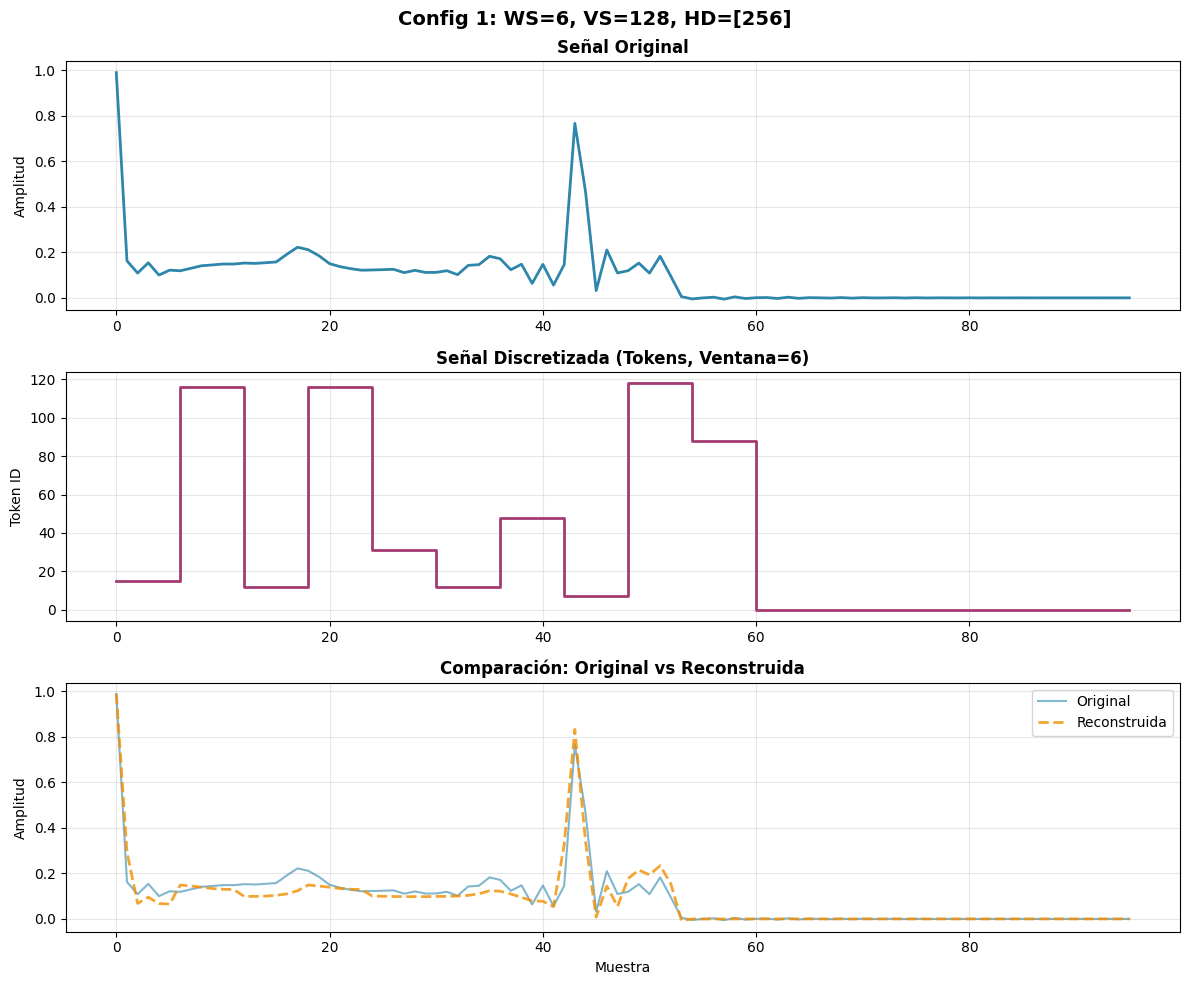

CONFIGURACIÓN 2/6
WINDOW_SIZE: 4, VOCAB_SIZE: 128, HIDDEN_DIMS: [256]
MSE de la reconstrucción: 0.000931


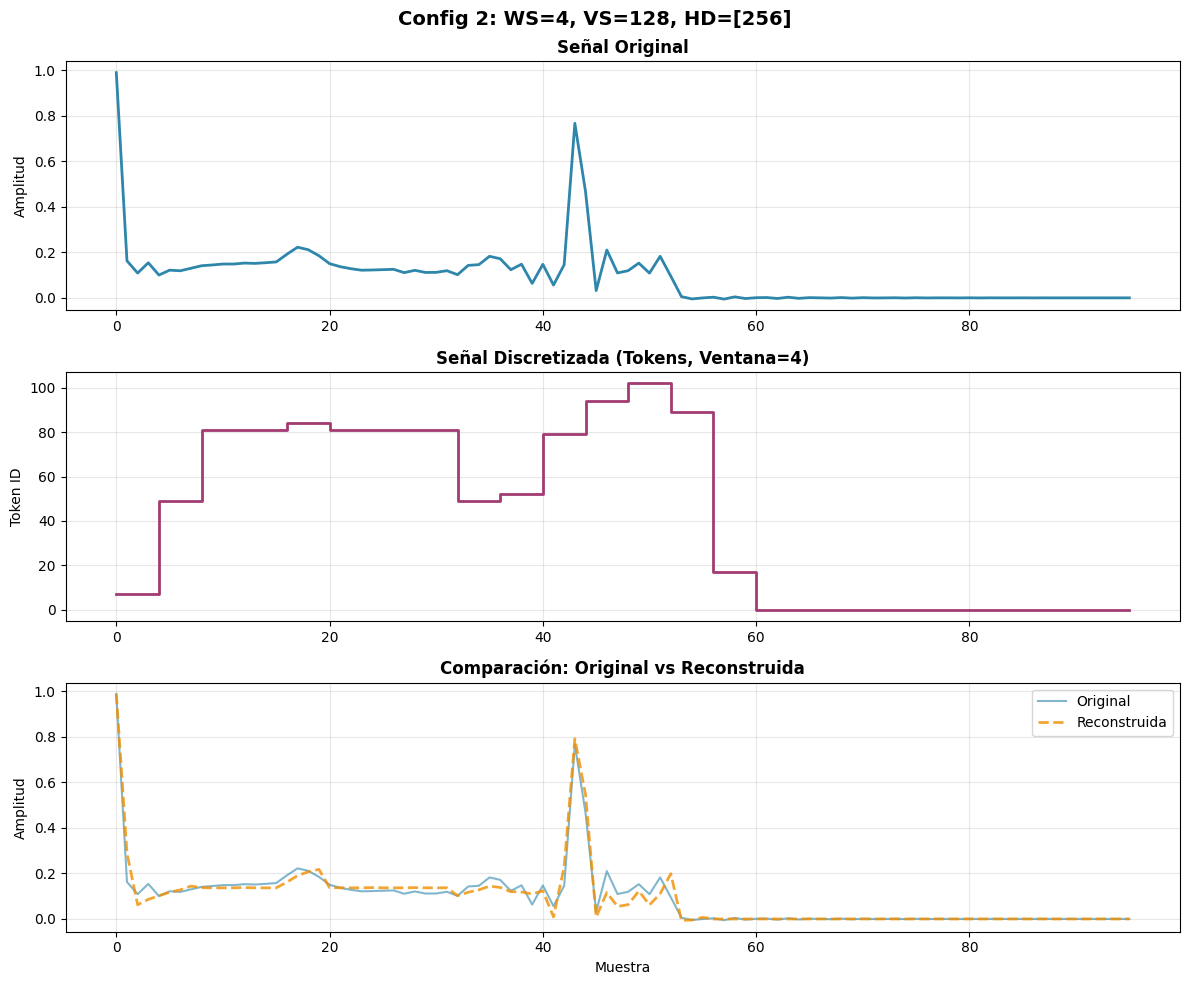

CONFIGURACIÓN 3/6
WINDOW_SIZE: 6, VOCAB_SIZE: 64, HIDDEN_DIMS: [256]
MSE de la reconstrucción: 0.002681


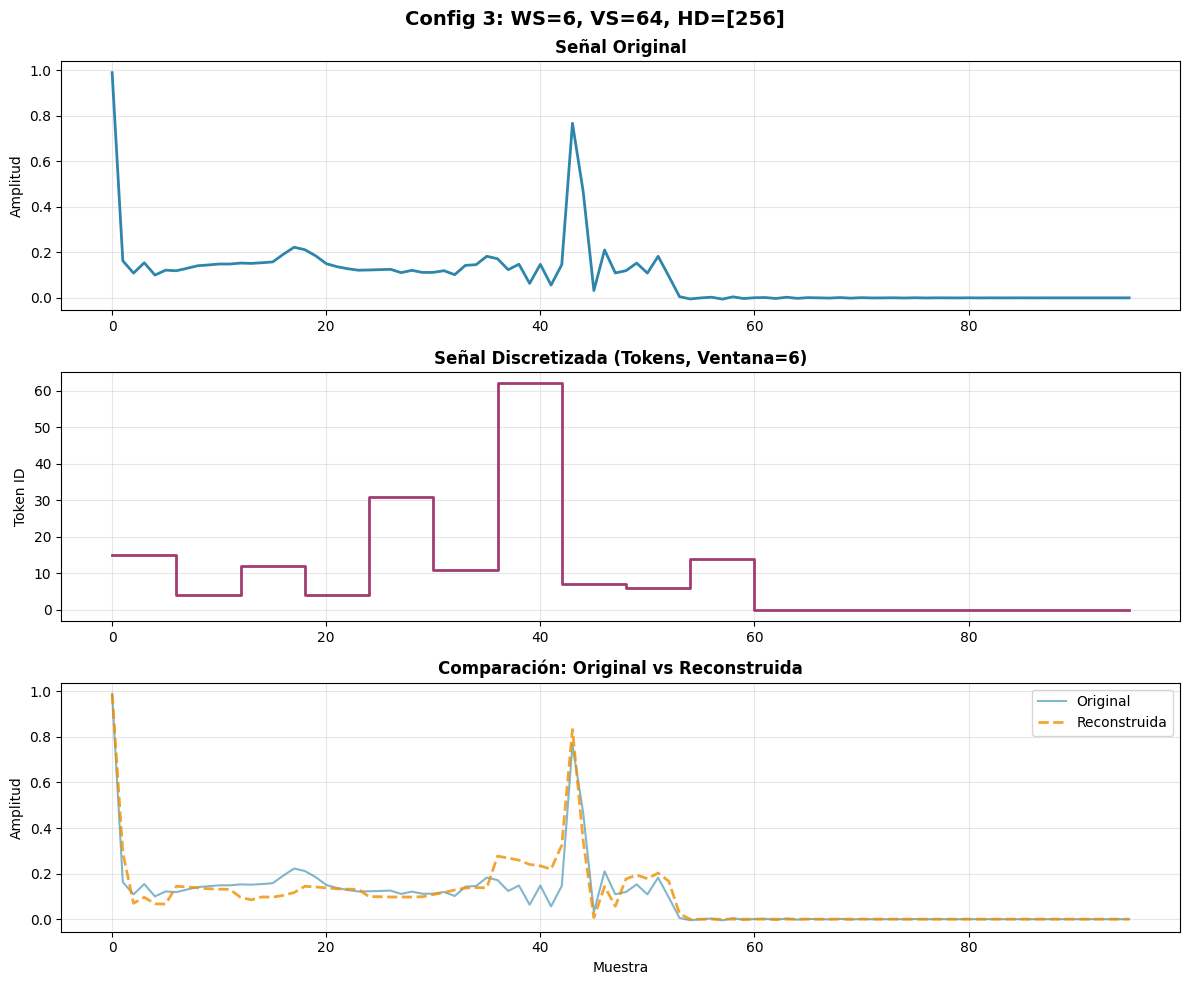

CONFIGURACIÓN 4/6
WINDOW_SIZE: 8, VOCAB_SIZE: 128, HIDDEN_DIMS: [512]
MSE de la reconstrucción: 0.002495


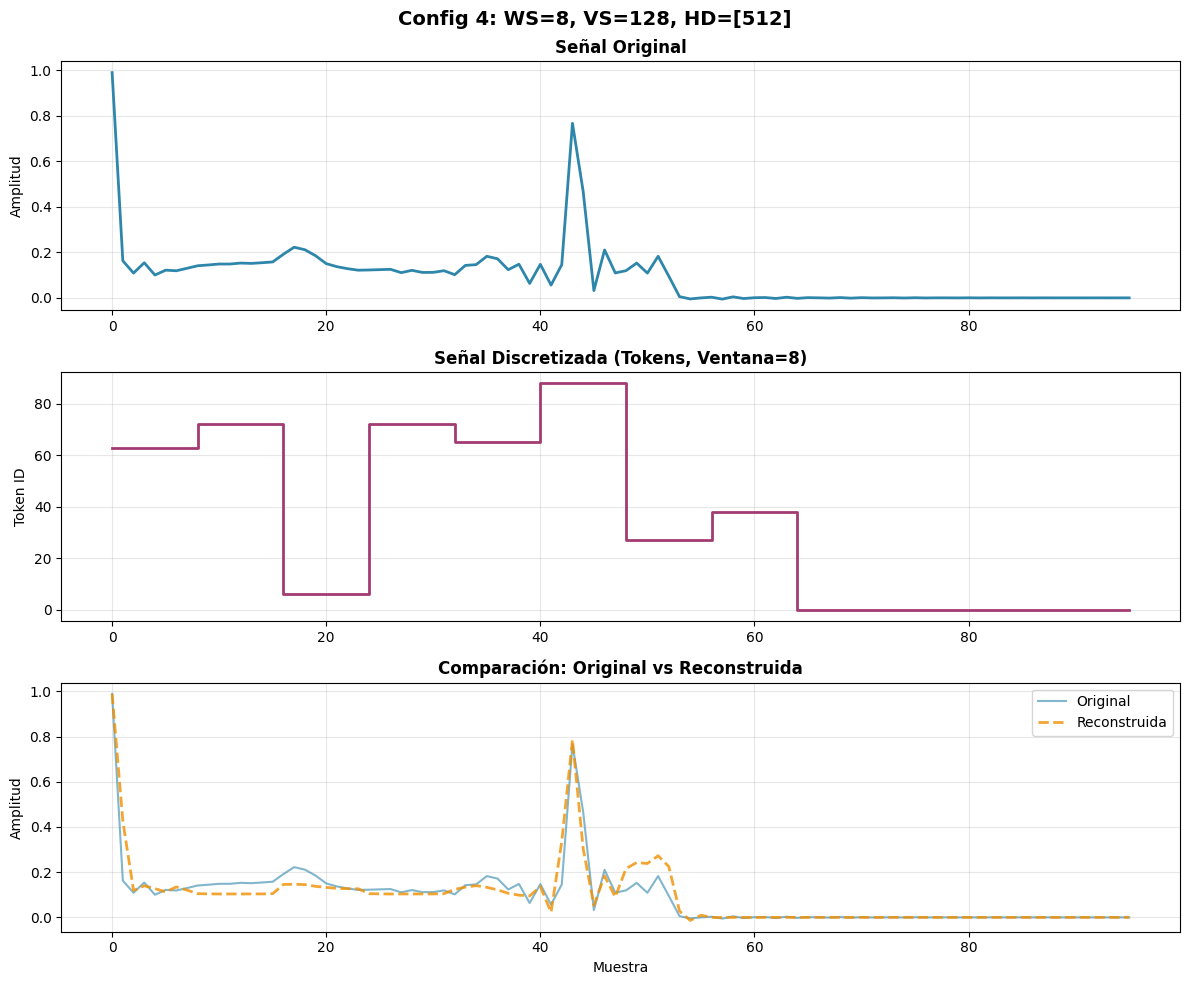

CONFIGURACIÓN 5/6
WINDOW_SIZE: 6, VOCAB_SIZE: 256, HIDDEN_DIMS: [128]
MSE de la reconstrucción: 0.001082


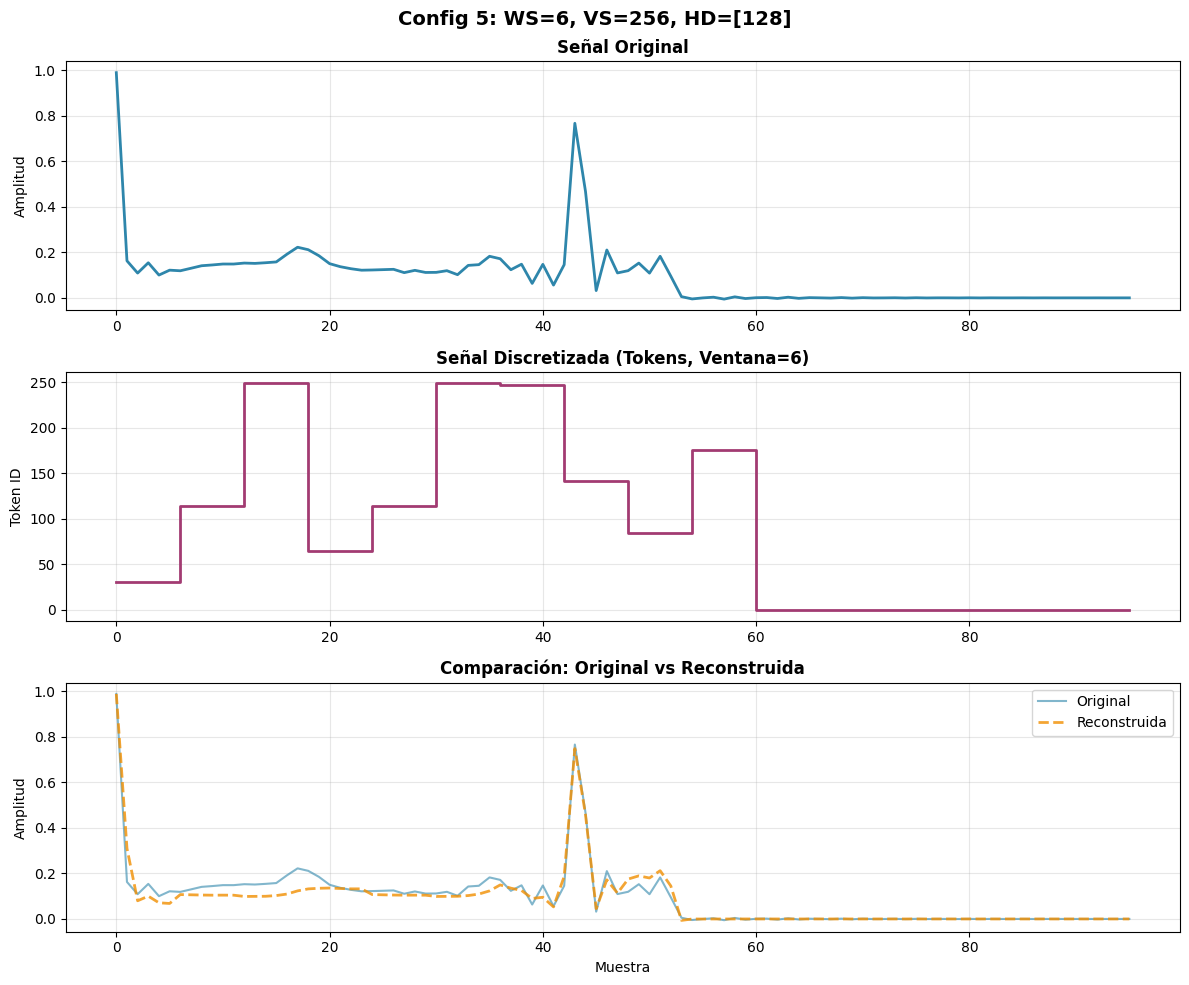

CONFIGURACIÓN 6/6
WINDOW_SIZE: 4, VOCAB_SIZE: 64, HIDDEN_DIMS: [512]
MSE de la reconstrucción: 0.002066


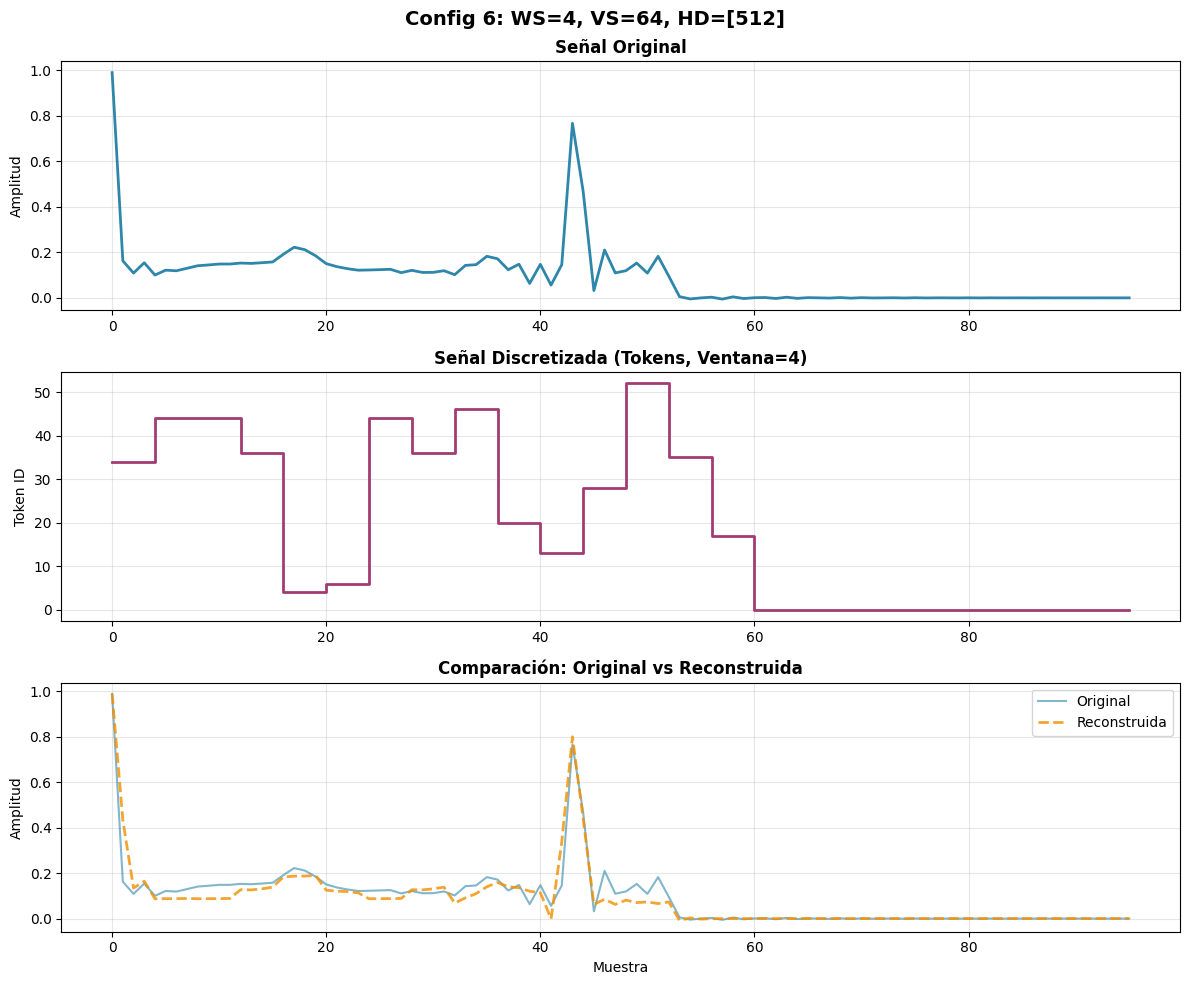

In [11]:
#Diferentes configuraciones de modelos 
param_grid = [
    {'WINDOW_SIZE': 6, 'VOCAB_SIZE': 128, 'HIDDEN_DIMS': [256]},
    {'WINDOW_SIZE': 4, 'VOCAB_SIZE': 128, 'HIDDEN_DIMS': [256]},
    {'WINDOW_SIZE': 6, 'VOCAB_SIZE': 64, 'HIDDEN_DIMS': [256]},
    {'WINDOW_SIZE': 8, 'VOCAB_SIZE': 128, 'HIDDEN_DIMS': [512]},
    {'WINDOW_SIZE': 6, 'VOCAB_SIZE': 256, 'HIDDEN_DIMS': [128]},
    {'WINDOW_SIZE': 4, 'VOCAB_SIZE': 64, 'HIDDEN_DIMS': [512]},
]

results = []

for idx, params in enumerate(param_grid):
    print(f"CONFIGURACIÓN {idx+1}/6")
    print(f"WINDOW_SIZE: {params['WINDOW_SIZE']}, VOCAB_SIZE: {params['VOCAB_SIZE']}, HIDDEN_DIMS: {params['HIDDEN_DIMS']}")
    
    WINDOW_SIZE = params['WINDOW_SIZE']
    VOCAB_SIZE = params['VOCAB_SIZE']
    HIDDEN_DIMS = params['HIDDEN_DIMS']
    
    #Discretización con GMM
    X_windows = X_discretization.reshape(-1, WINDOW_SIZE)
    gmm = GaussianMixture(n_components=VOCAB_SIZE, covariance_type='full', random_state=42)
    gmm.fit(X_windows)
    
    #Visualización 
    sample_signal = X_discretization[0:1]
    sample_tokens = discretize_signals(sample_signal, WINDOW_SIZE, gmm)
    sample_reconstructed = reconstruct_signals(sample_tokens, WINDOW_SIZE, gmm)
    sample_discretized = np.repeat(sample_tokens[0], WINDOW_SIZE)
    mse = np.mean((sample_signal - sample_reconstructed) ** 2)
    print(f"MSE de la reconstrucción: {mse:.6f}")
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    fig.suptitle(f'Config {idx+1}: WS={WINDOW_SIZE}, VS={VOCAB_SIZE}, HD={HIDDEN_DIMS}', fontsize=14, fontweight='bold')
    
    axes[0].plot(sample_signal[0], color='#2E86AB', linewidth=2)
    axes[0].set_title('Señal Original', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Amplitud')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].step(range(len(sample_discretized)), sample_discretized, where='post', color='#A23B72', linewidth=2)
    axes[1].set_title(f'Señal Discretizada (Tokens, Ventana={WINDOW_SIZE})', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Token ID')
    axes[1].grid(True, alpha=0.3)
    
    axes[2].plot(sample_signal[0], label='Original', alpha=0.6, color='#2E86AB', linewidth=1.5)
    axes[2].plot(sample_reconstructed[0], label='Reconstruida', alpha=0.8, color='#F18F01', linewidth=2, linestyle='--')
    axes[2].set_title('Comparación: Original vs Reconstruida', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Amplitud')
    axes[2].set_xlabel('Muestra')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    results.append({
        'params': params,
        'gmm': gmm,
        'WINDOW_SIZE': WINDOW_SIZE,
        'VOCAB_SIZE': VOCAB_SIZE,
        'HIDDEN_DIMS': HIDDEN_DIMS
    })

In [12]:
for idx, result in enumerate(results):
    WINDOW_SIZE = result['WINDOW_SIZE']
    VOCAB_SIZE = result['VOCAB_SIZE']
    gmm = result['gmm']
    
    X_autoreg_tokens = discretize_signals(X_autoreg, WINDOW_SIZE, gmm)
    X_train, X_temp = train_test_split(X_autoreg_tokens, test_size=0.5, random_state=42)
    X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=42)
    
    train_ds = ECGTokenDataset(X_train, VOCAB_SIZE)
    val_ds = ECGTokenDataset(X_val, VOCAB_SIZE)
    test_ds = ECGTokenDataset(X_test, VOCAB_SIZE)
    
    train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=64, shuffle=False)
    
    result['train_ds'] = train_ds
    result['val_ds'] = val_ds
    result['test_ds'] = test_ds
    result['train_dl'] = train_dl
    result['val_dl'] = val_dl
    result['X_test'] = X_test


ENTRENANDO CONFIGURACIÓN 1/6
WINDOW_SIZE: 6, VOCAB_SIZE: 128, HIDDEN_DIMS: [256]


T-Loss: 30.8305 V-Loss: 35.4215: 100%|██████████| 100/100 [01:08<00:00,  1.46it/s] 


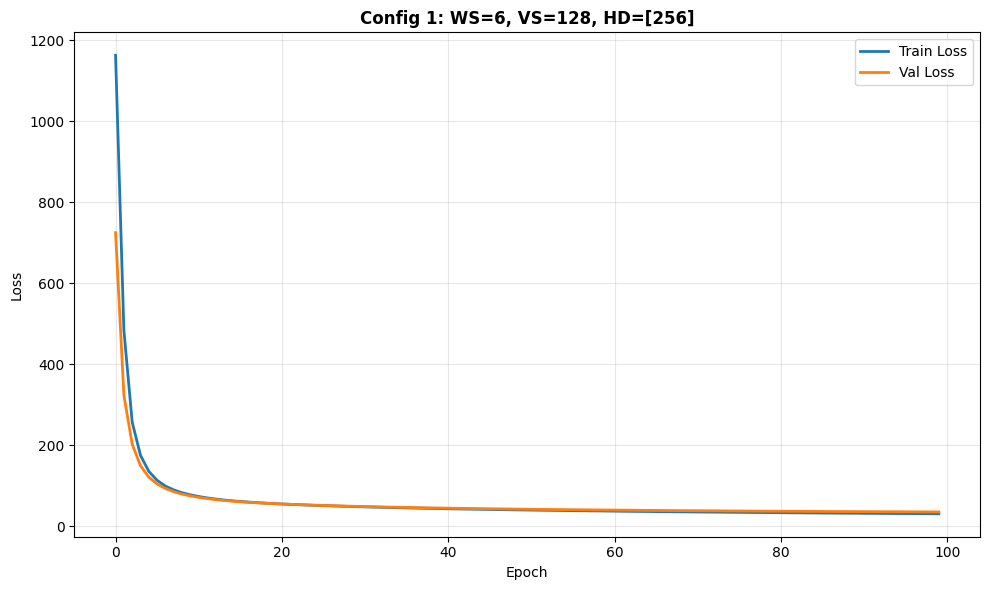

ENTRENANDO CONFIGURACIÓN 2/6
WINDOW_SIZE: 4, VOCAB_SIZE: 128, HIDDEN_DIMS: [256]


T-Loss: 45.7535 V-Loss: 55.1993: 100%|██████████| 100/100 [01:24<00:00,  1.19it/s] 


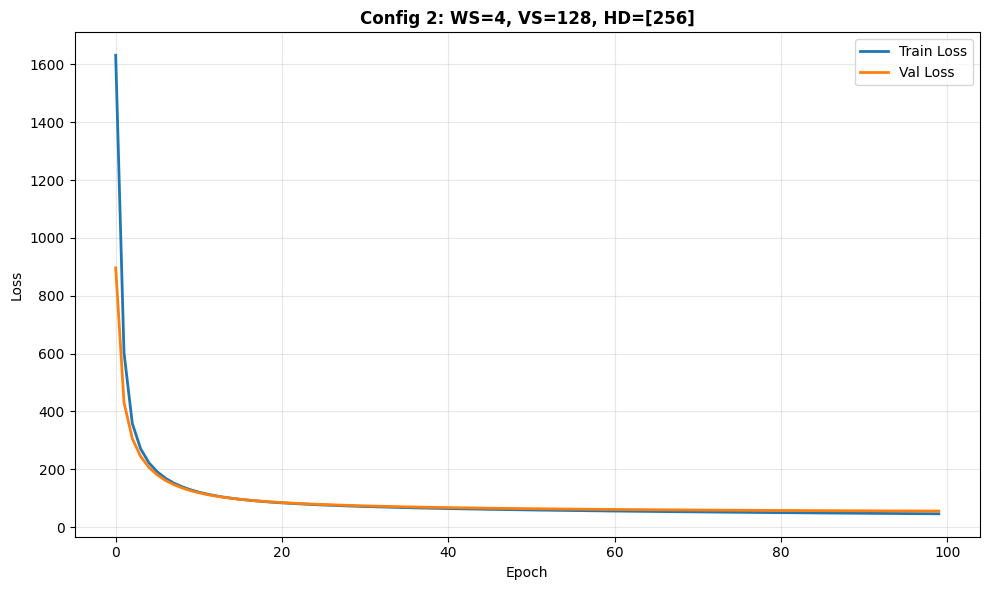

ENTRENANDO CONFIGURACIÓN 3/6
WINDOW_SIZE: 6, VOCAB_SIZE: 64, HIDDEN_DIMS: [256]


T-Loss: 23.5750 V-Loss: 27.0415: 100%|██████████| 100/100 [00:55<00:00,  1.79it/s]


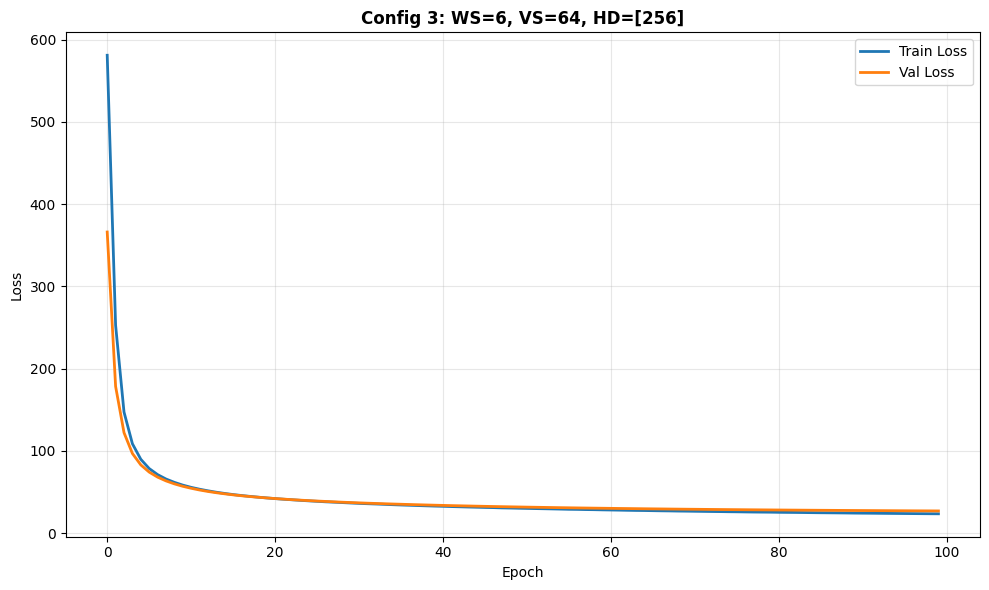

ENTRENANDO CONFIGURACIÓN 4/6
WINDOW_SIZE: 8, VOCAB_SIZE: 128, HIDDEN_DIMS: [512]


T-Loss: 20.2333 V-Loss: 24.2650: 100%|██████████| 100/100 [01:21<00:00,  1.23it/s]


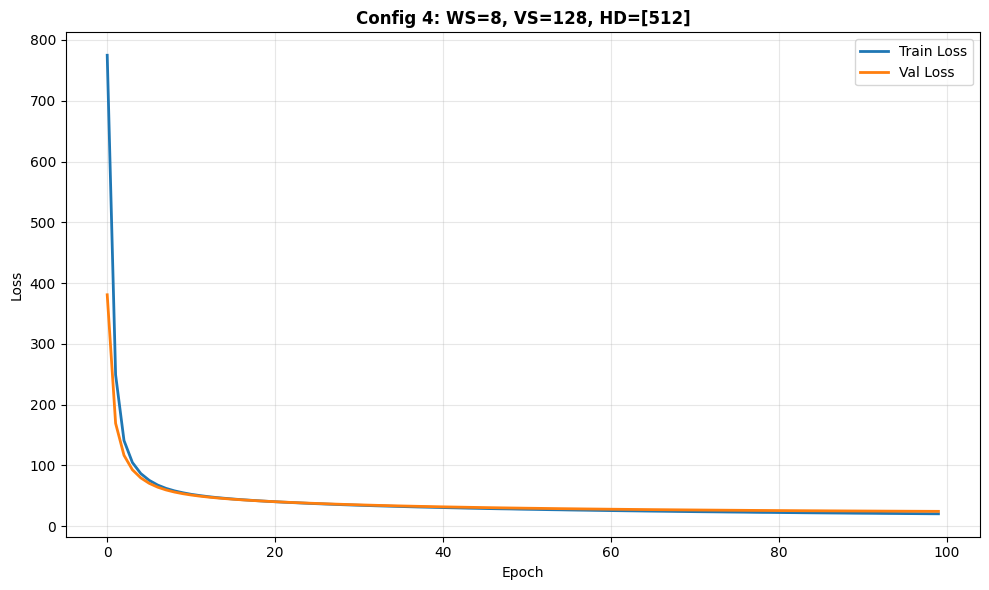

ENTRENANDO CONFIGURACIÓN 5/6
WINDOW_SIZE: 6, VOCAB_SIZE: 256, HIDDEN_DIMS: [128]


T-Loss: 42.9373 V-Loss: 45.9420: 100%|██████████| 100/100 [01:16<00:00,  1.30it/s]  


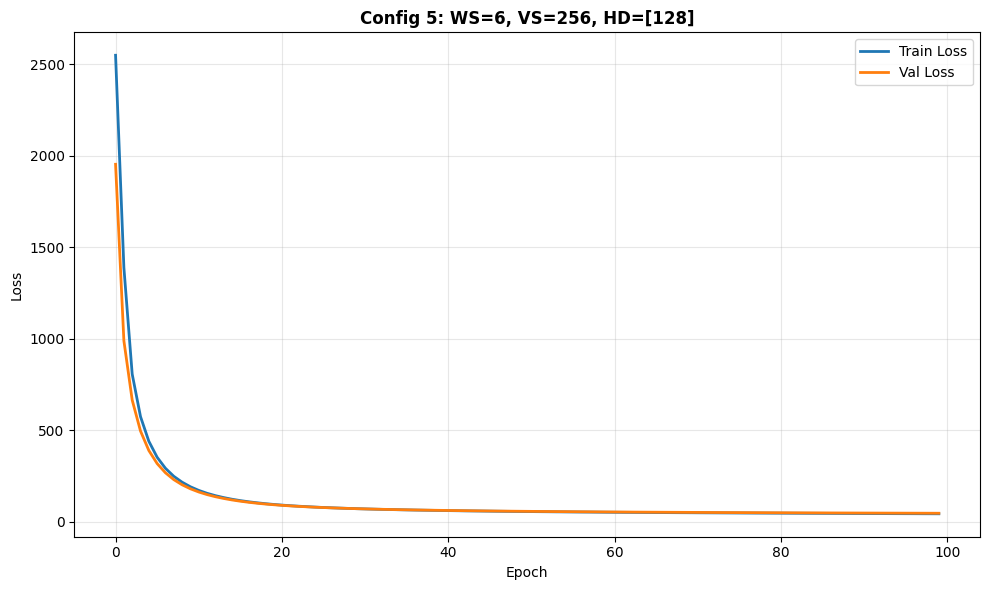

ENTRENANDO CONFIGURACIÓN 6/6
WINDOW_SIZE: 4, VOCAB_SIZE: 64, HIDDEN_DIMS: [512]


T-Loss: 29.4691 V-Loss: 40.5384: 100%|██████████| 100/100 [01:37<00:00,  1.03it/s]


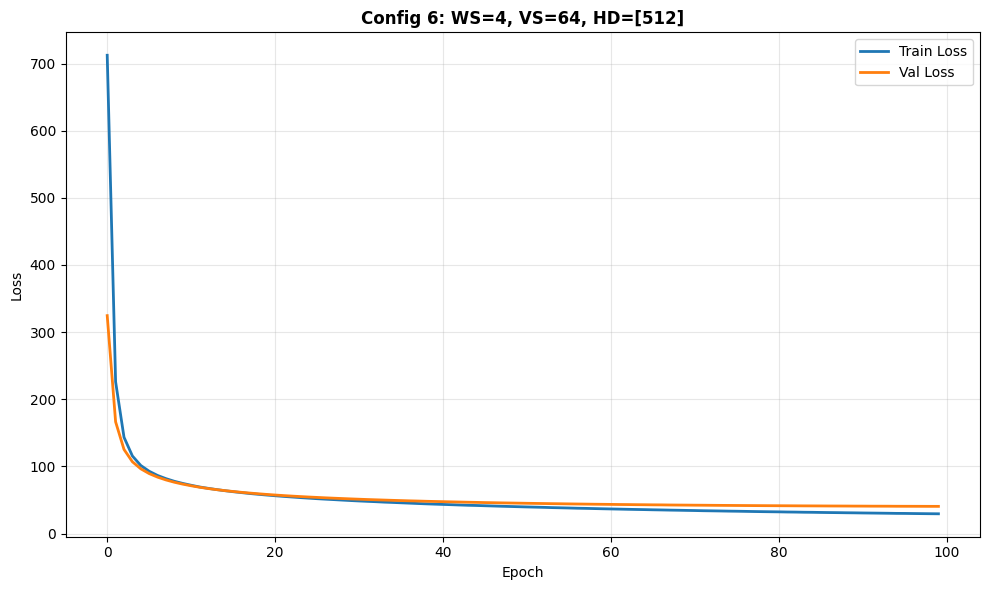

In [13]:
LR = 1e-3
EPOCHS = 100

def loss_fn(inputs, preds):
    loss = F.binary_cross_entropy_with_logits(preds, inputs, reduction='none')
    return loss.sum(dim=1).mean()

def train_validate_loop(model, optimizer, scheduler, loss_fn, train_loader, val_loader, epochs):
    train_losses = []
    val_losses = []
    
    pbar = tqdm(range(epochs))
    for epoch in pbar:
        model.train()
        running_loss = 0.0
        for i, data in enumerate(train_loader):
            inputs = data.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(inputs, outputs)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for i, data in enumerate(val_loader):
                inputs = data.to(device)
                outputs = model(inputs)
                loss = loss_fn(inputs, outputs)
                running_val_loss += loss.item()
        
        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        if scheduler:
            scheduler.step()
            
        pbar.set_description(f'T-Loss: {avg_train_loss:.4f} V-Loss: {avg_val_loss:.4f}')

    return train_losses, val_losses

#Entrenamiento para todos los modelos definidos anteriormente 
for idx, result in enumerate(results):
    print(f"ENTRENANDO CONFIGURACIÓN {idx+1}/6")
    print(f"WINDOW_SIZE: {result['WINDOW_SIZE']}, VOCAB_SIZE: {result['VOCAB_SIZE']}, HIDDEN_DIMS: {result['HIDDEN_DIMS']}")
    
    seq_len = X_padded.shape[1] // result['WINDOW_SIZE']
    input_dim = seq_len * result['VOCAB_SIZE']
    
    made_model = models.MADE(input_dim=input_dim, hidden_dims=result['HIDDEN_DIMS'], n_masks=1)
    made_model.to(device)
    
    optimizer = optim.Adam(made_model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = lr_scheduler.MultiplicativeLR(optimizer, lr_lambda=lambda _: 0.99)
    
    train_hist, val_hist = train_validate_loop(made_model, optimizer, scheduler, loss_fn, 
                                                result['train_dl'], result['val_dl'], EPOCHS)
    
    result['model'] = made_model
    result['train_hist'] = train_hist
    result['val_hist'] = val_hist
    result['seq_len'] = seq_len
    
    #Curvas de entrenamiento
    plt.figure(figsize=(10, 6))
    plt.plot(train_hist, label='Train Loss', linewidth=2)
    plt.plot(val_hist, label='Val Loss', linewidth=2)
    plt.title(f'Config {idx+1}: WS={result["WINDOW_SIZE"]}, VS={result["VOCAB_SIZE"]}, HD={result["HIDDEN_DIMS"]}', 
              fontsize=12, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


EVALUANDO CONFIGURACIÓN 1/6
WINDOW_SIZE: 6, VOCAB_SIZE: 128, HIDDEN_DIMS: [256]


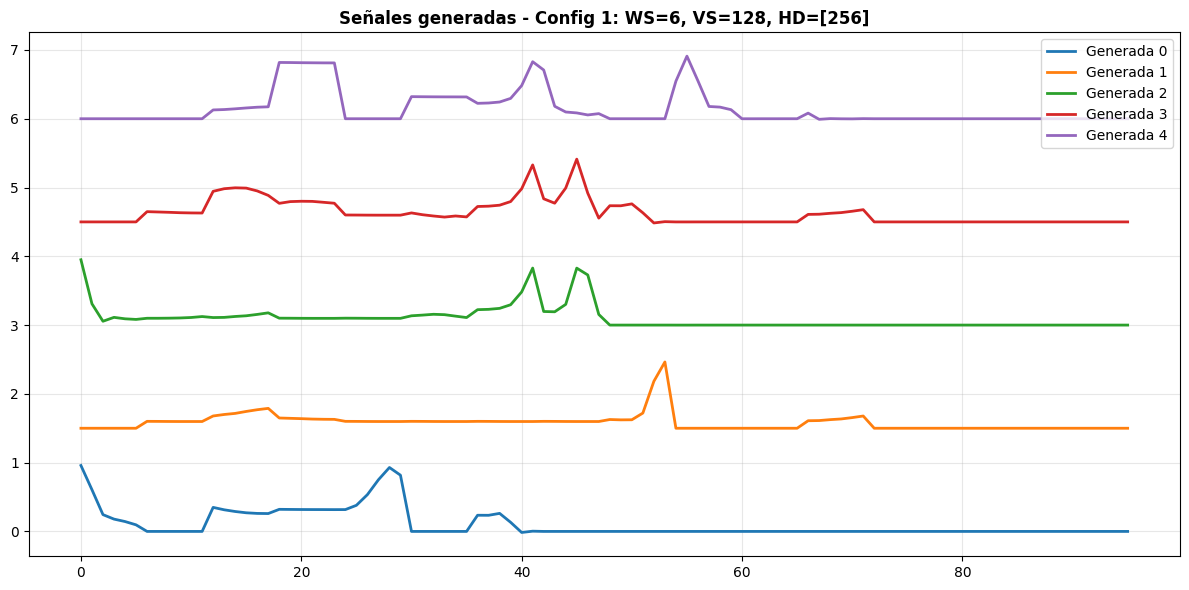

NLL promedio en Train: 30.6835
NLL promedio en Val: 35.3952
NLL promedio en Test: 35.6762


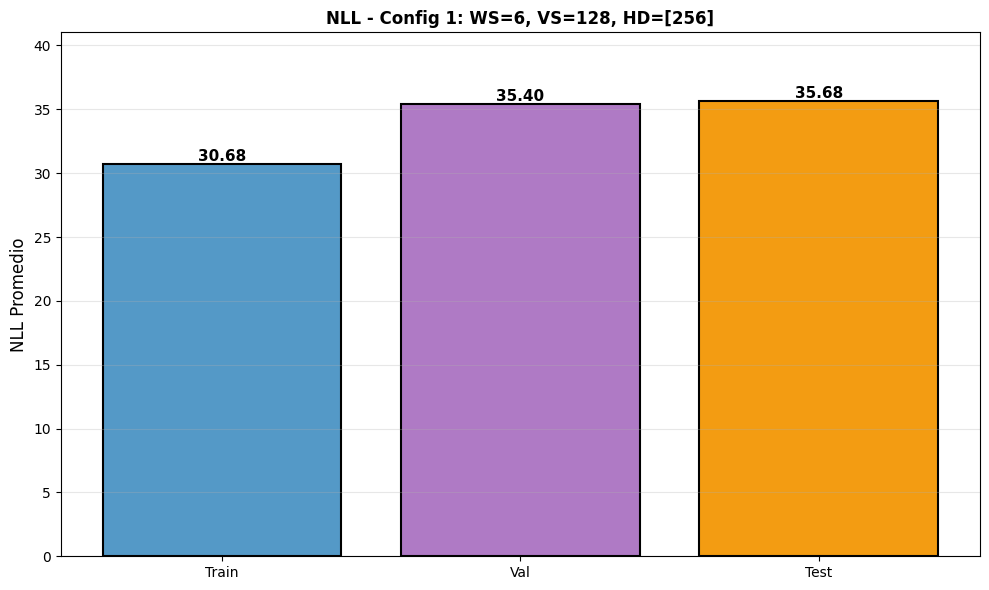

NLL promedio en Anomalías: 54.1125
Diferencia: 18.4363

Comparación Generadas vs Reales
Distancia Euclidiana promedio: 2.2457 ± 0.7209
Correlación de Pearson promedio: 0.3570 ± 0.1968


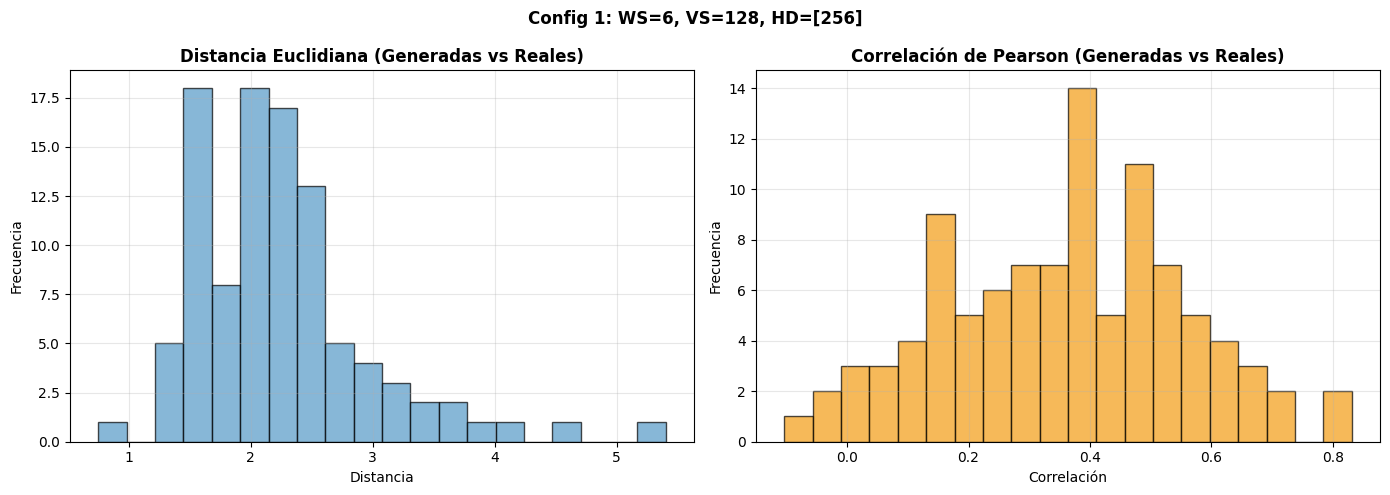


--------------------------------------------------------------------------------

EVALUANDO CONFIGURACIÓN 2/6
WINDOW_SIZE: 4, VOCAB_SIZE: 128, HIDDEN_DIMS: [256]


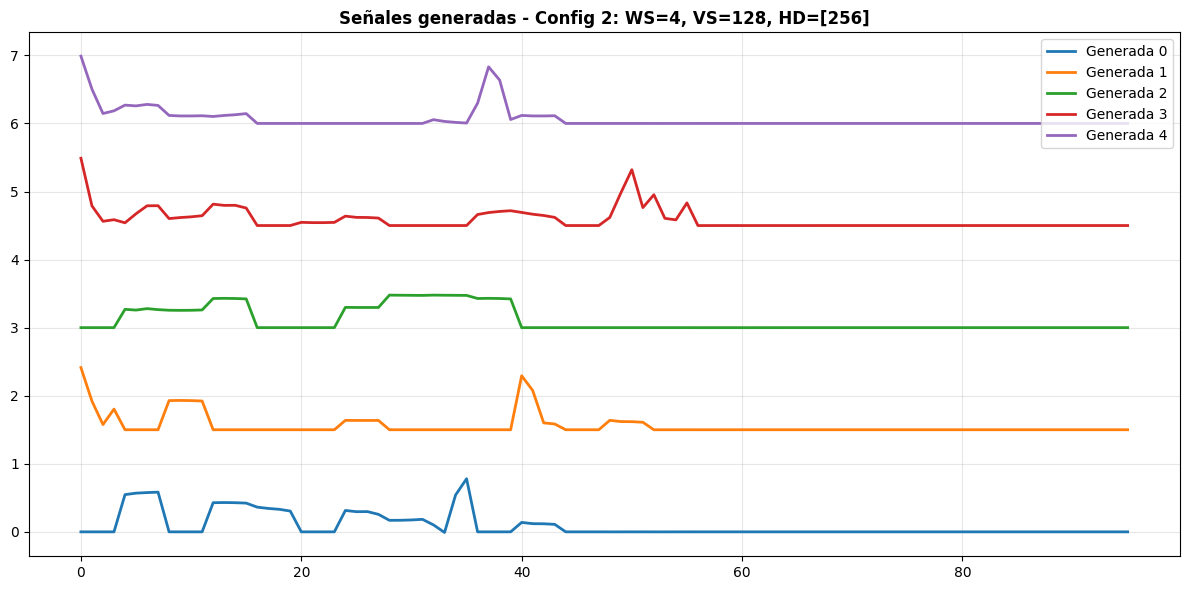

NLL promedio en Train: 45.5273
NLL promedio en Val: 55.1751
NLL promedio en Test: 54.8307


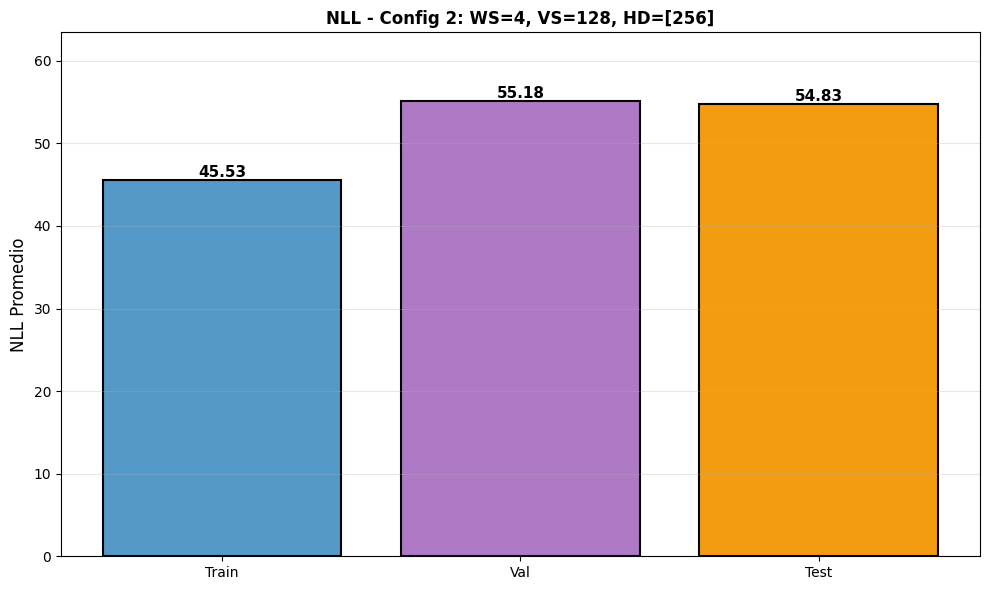

NLL promedio en Anomalías: 83.3770
Diferencia: 28.5463

Comparación Generadas vs Reales
Distancia Euclidiana promedio: 2.1855 ± 0.7083
Correlación de Pearson promedio: 0.3849 ± 0.1820


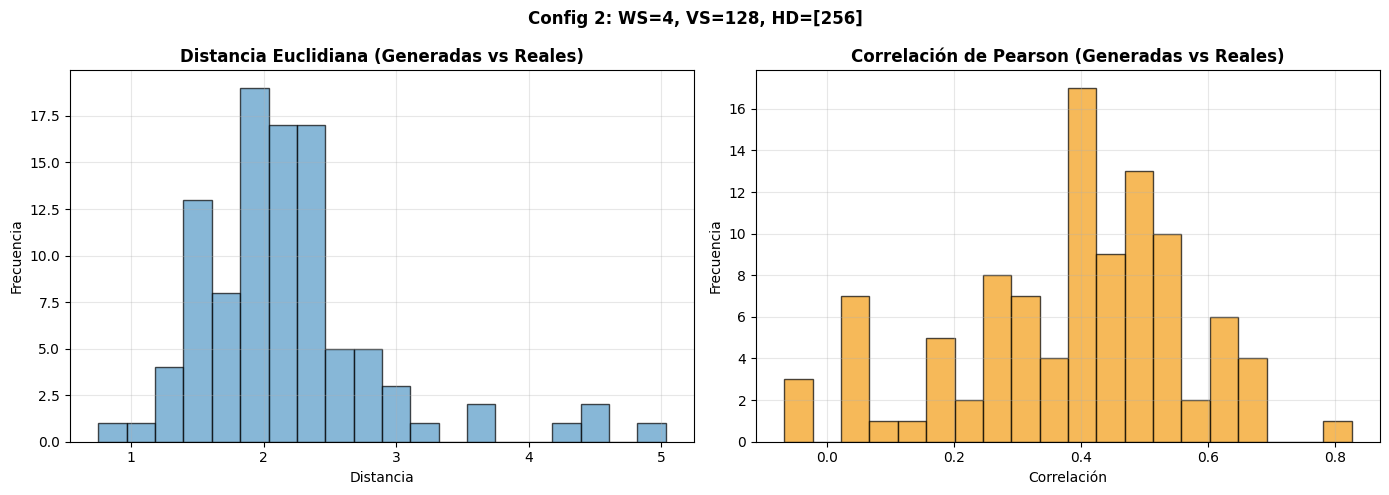


--------------------------------------------------------------------------------

EVALUANDO CONFIGURACIÓN 3/6
WINDOW_SIZE: 6, VOCAB_SIZE: 64, HIDDEN_DIMS: [256]


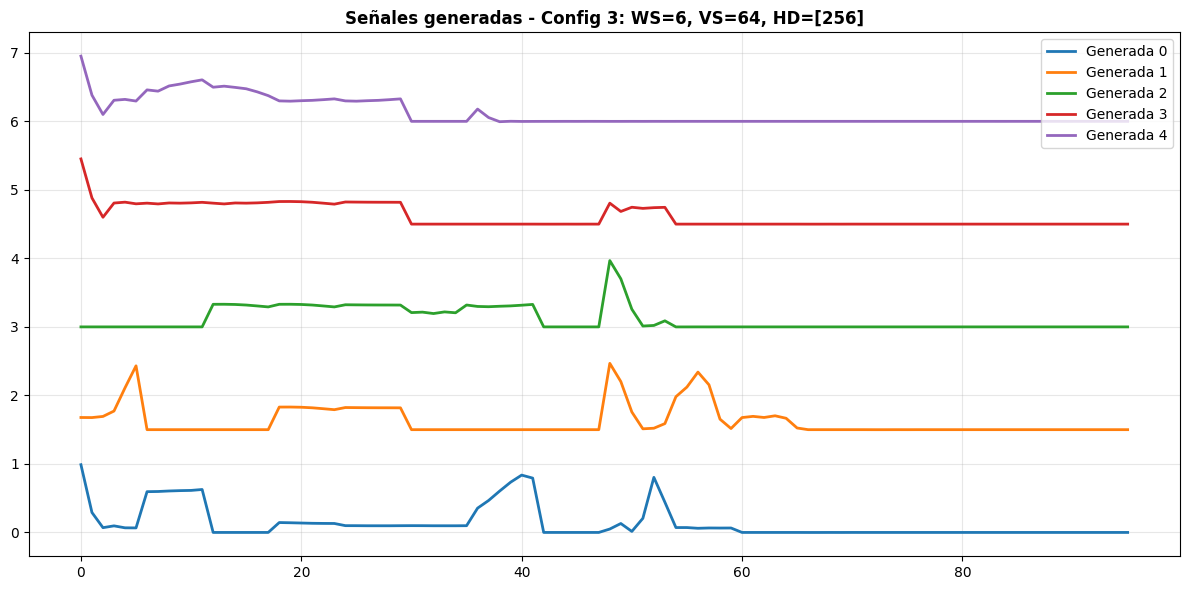

NLL promedio en Train: 23.4644
NLL promedio en Val: 27.0424
NLL promedio en Test: 27.5487


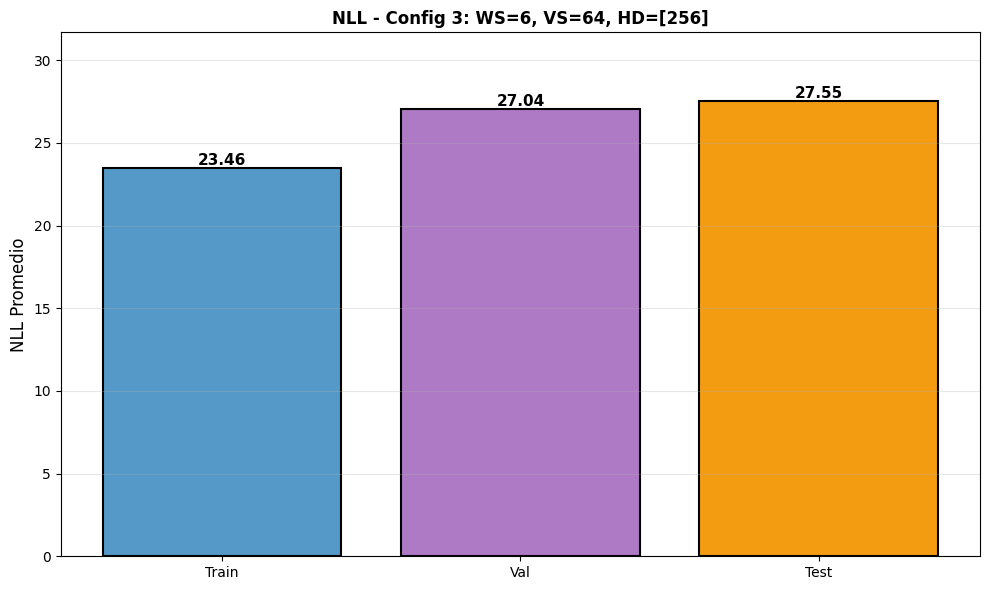

NLL promedio en Anomalías: 45.2978
Diferencia: 17.7491

Comparación Generadas vs Reales
Distancia Euclidiana promedio: 1.9082 ± 0.6148
Correlación de Pearson promedio: 0.4848 ± 0.1932


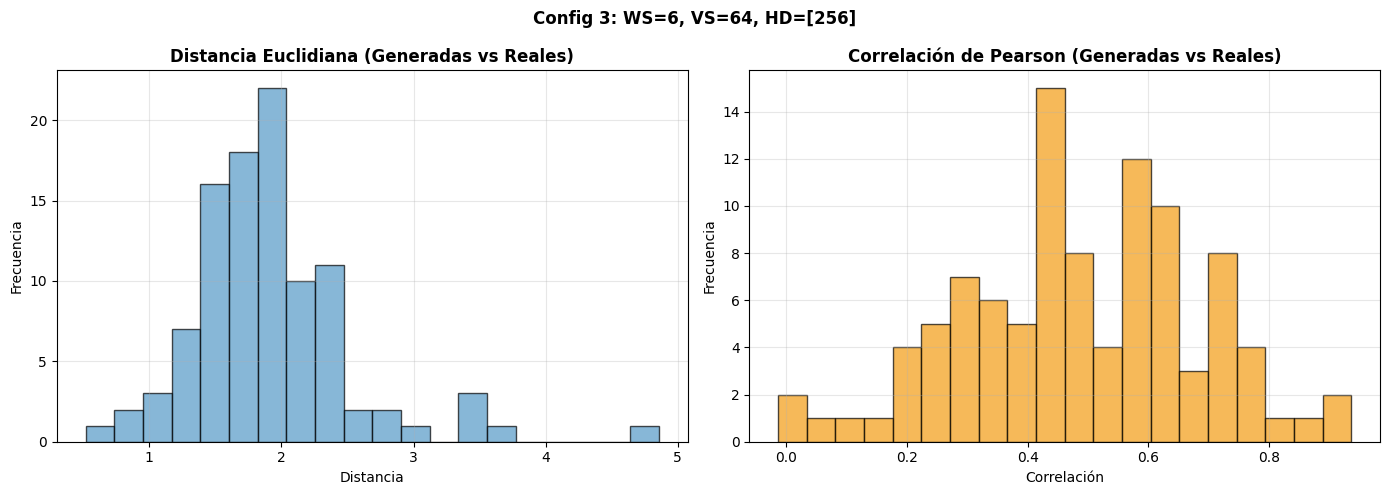


--------------------------------------------------------------------------------

EVALUANDO CONFIGURACIÓN 4/6
WINDOW_SIZE: 8, VOCAB_SIZE: 128, HIDDEN_DIMS: [512]


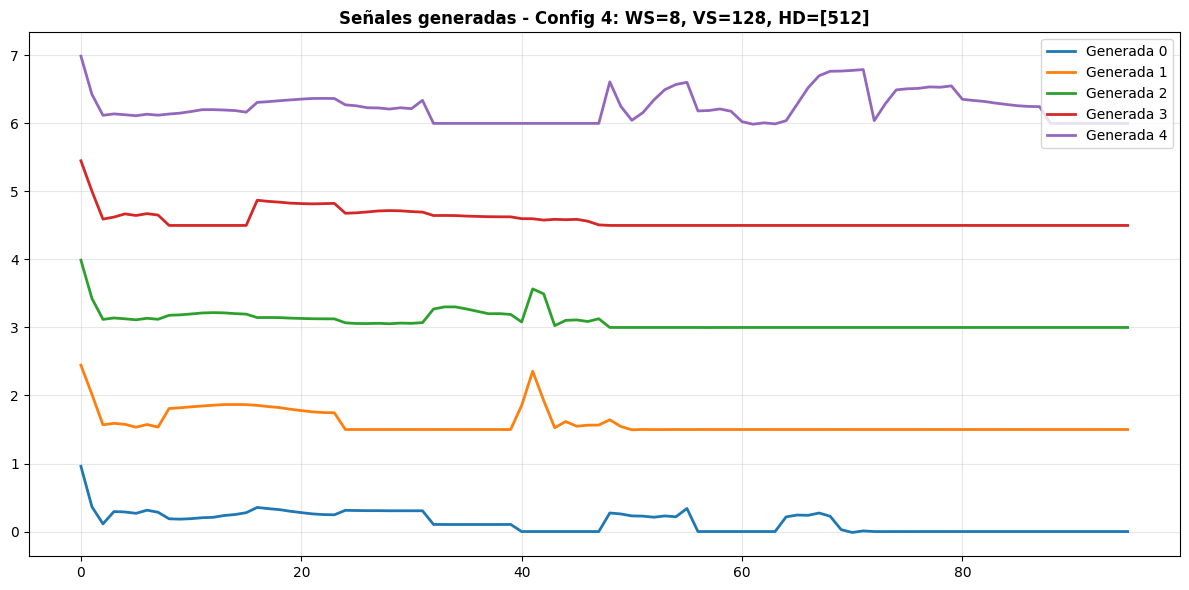

NLL promedio en Train: 20.1121
NLL promedio en Val: 24.2526
NLL promedio en Test: 24.8264


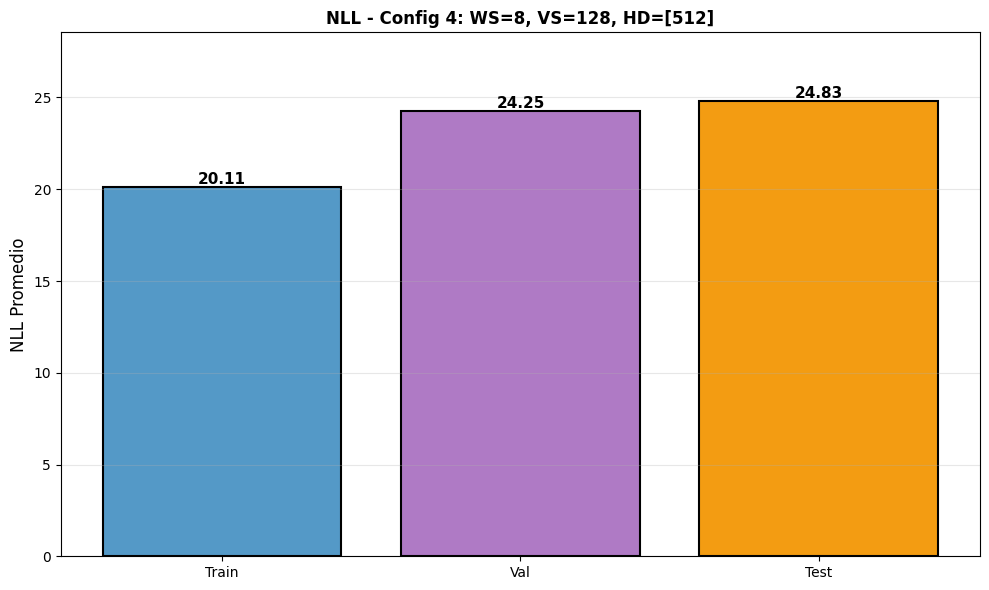

NLL promedio en Anomalías: 41.7149
Diferencia: 16.8885

Comparación Generadas vs Reales
Distancia Euclidiana promedio: 2.0756 ± 0.6125
Correlación de Pearson promedio: 0.4229 ± 0.2029


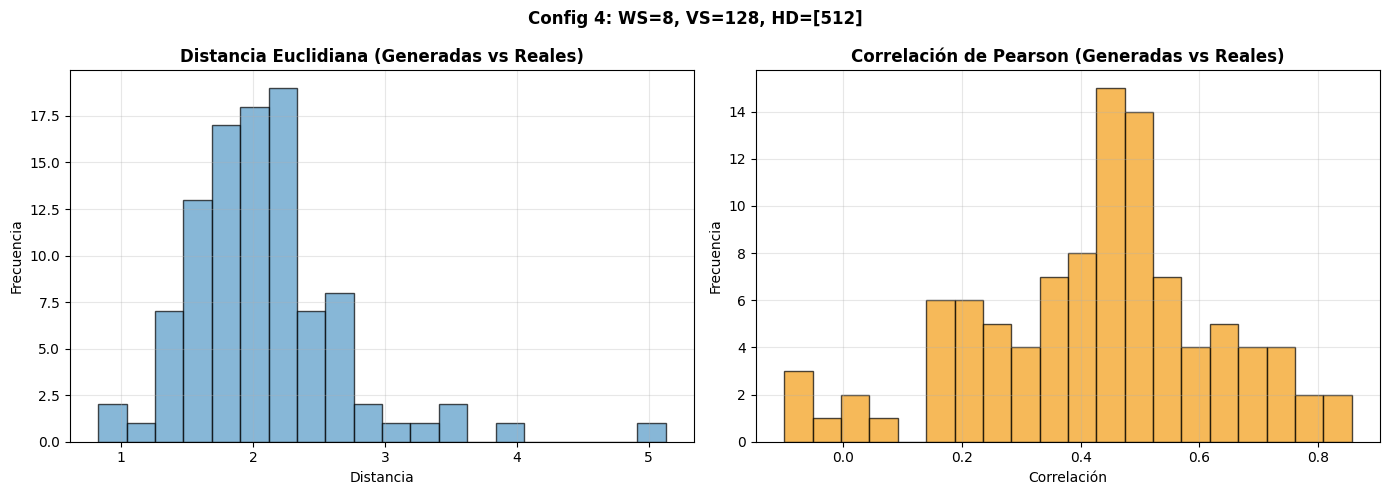


--------------------------------------------------------------------------------

EVALUANDO CONFIGURACIÓN 5/6
WINDOW_SIZE: 6, VOCAB_SIZE: 256, HIDDEN_DIMS: [128]


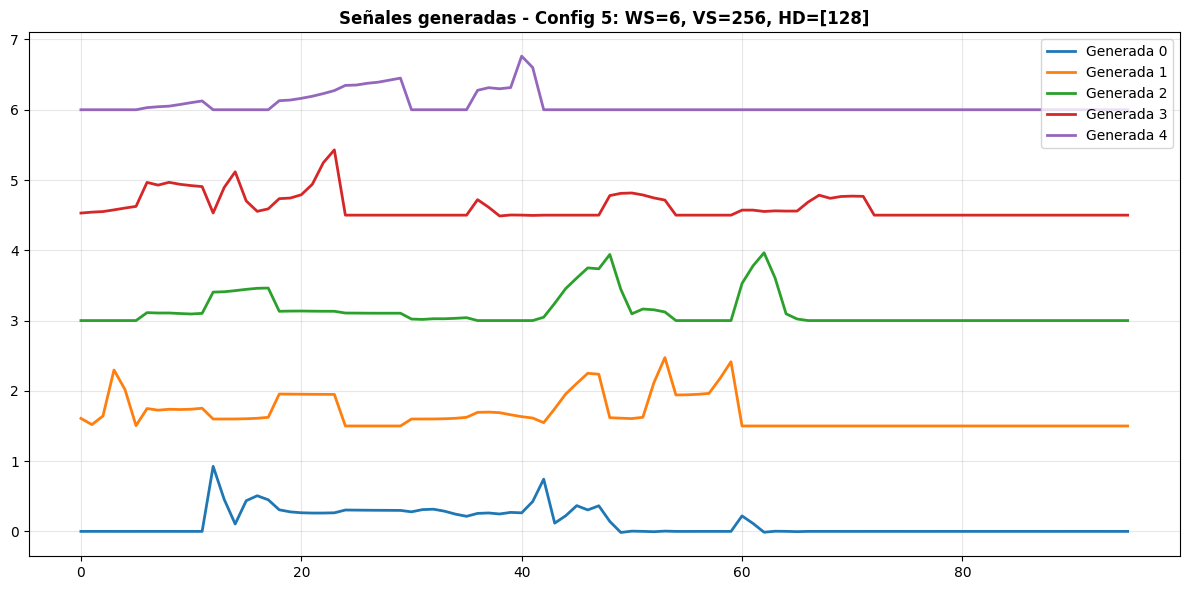

NLL promedio en Train: 42.8148
NLL promedio en Val: 45.9284
NLL promedio en Test: 46.4027


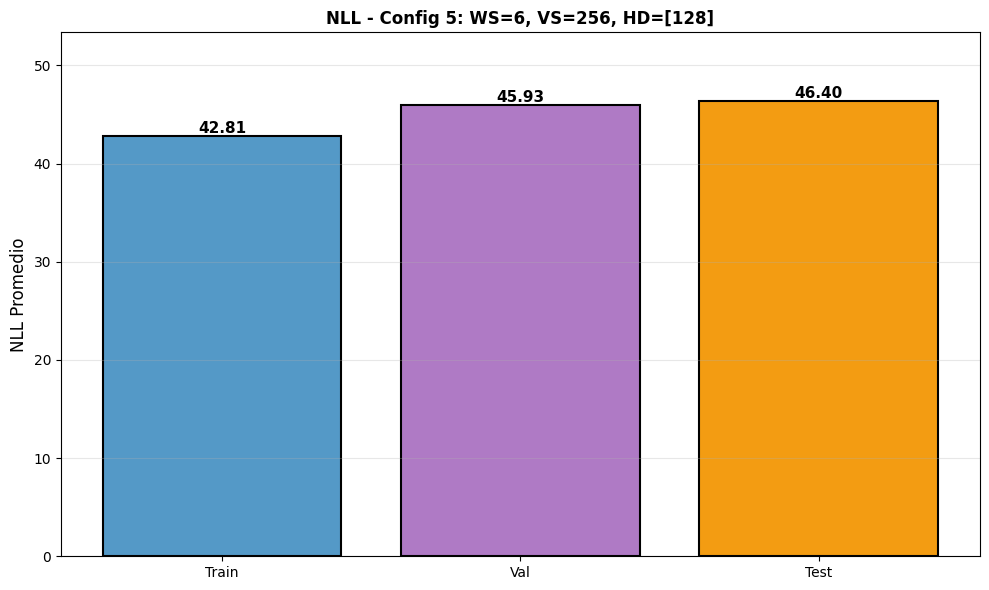

NLL promedio en Anomalías: 64.3823
Diferencia: 17.9796

Comparación Generadas vs Reales
Distancia Euclidiana promedio: 2.2505 ± 0.6773
Correlación de Pearson promedio: 0.3262 ± 0.2119


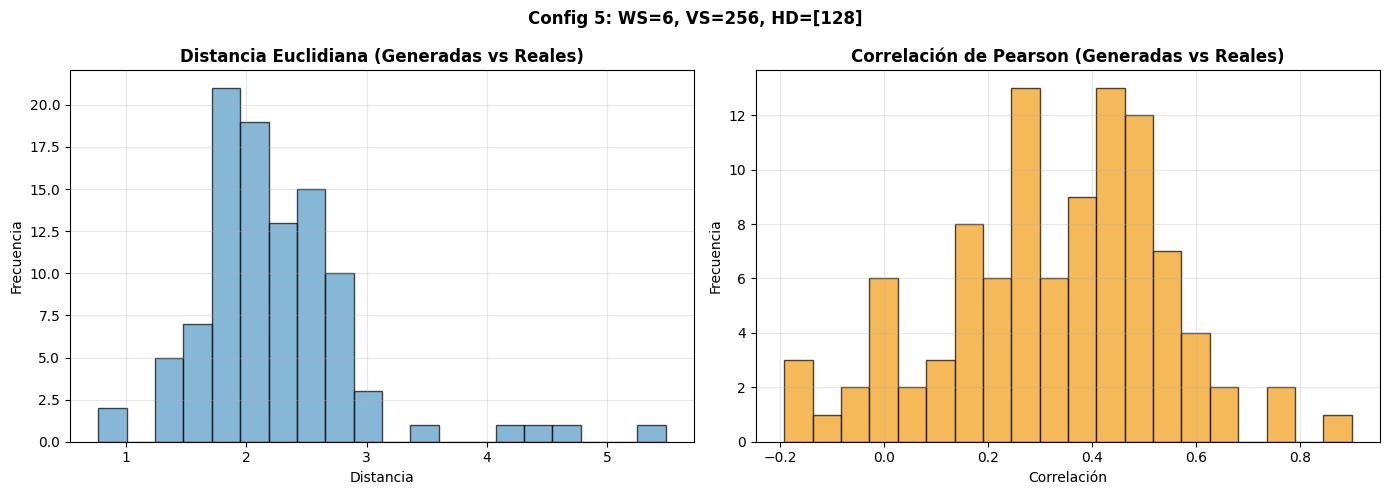


--------------------------------------------------------------------------------

EVALUANDO CONFIGURACIÓN 6/6
WINDOW_SIZE: 4, VOCAB_SIZE: 64, HIDDEN_DIMS: [512]


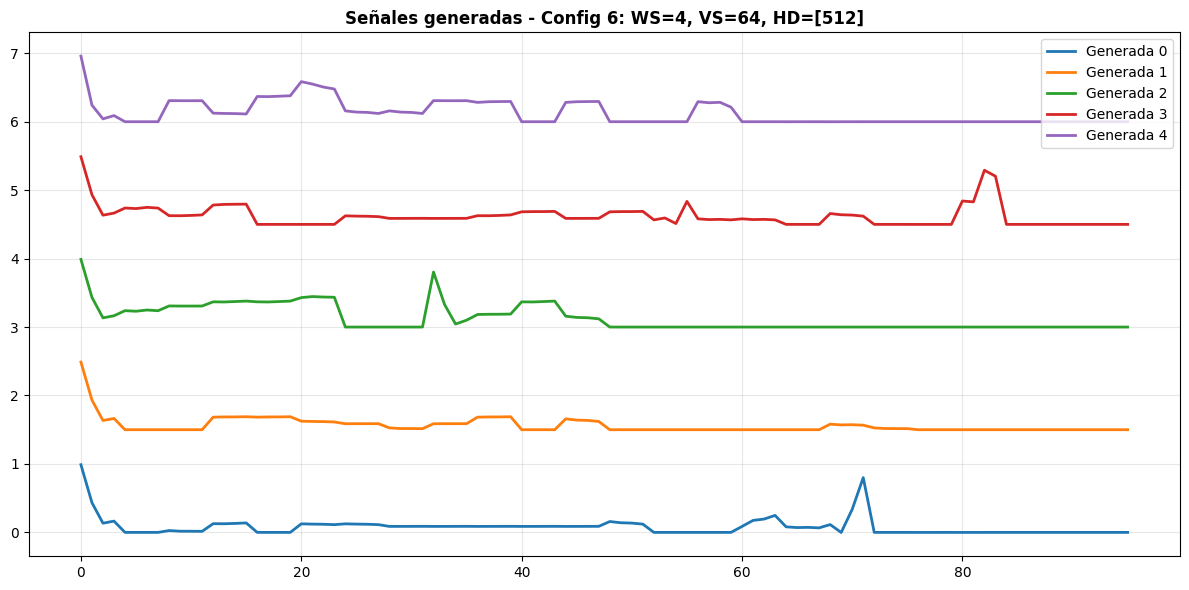

NLL promedio en Train: 29.2542
NLL promedio en Val: 40.5035
NLL promedio en Test: 41.1911


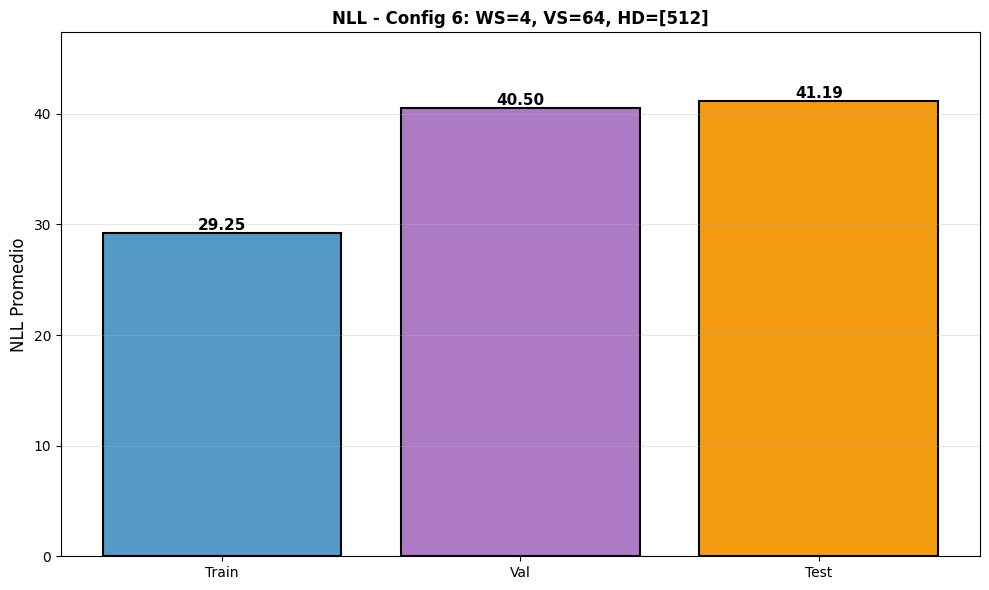

NLL promedio en Anomalías: 72.7776
Diferencia: 31.5865

Comparación Generadas vs Reales
Distancia Euclidiana promedio: 1.9986 ± 0.7238
Correlación de Pearson promedio: 0.4557 ± 0.2018


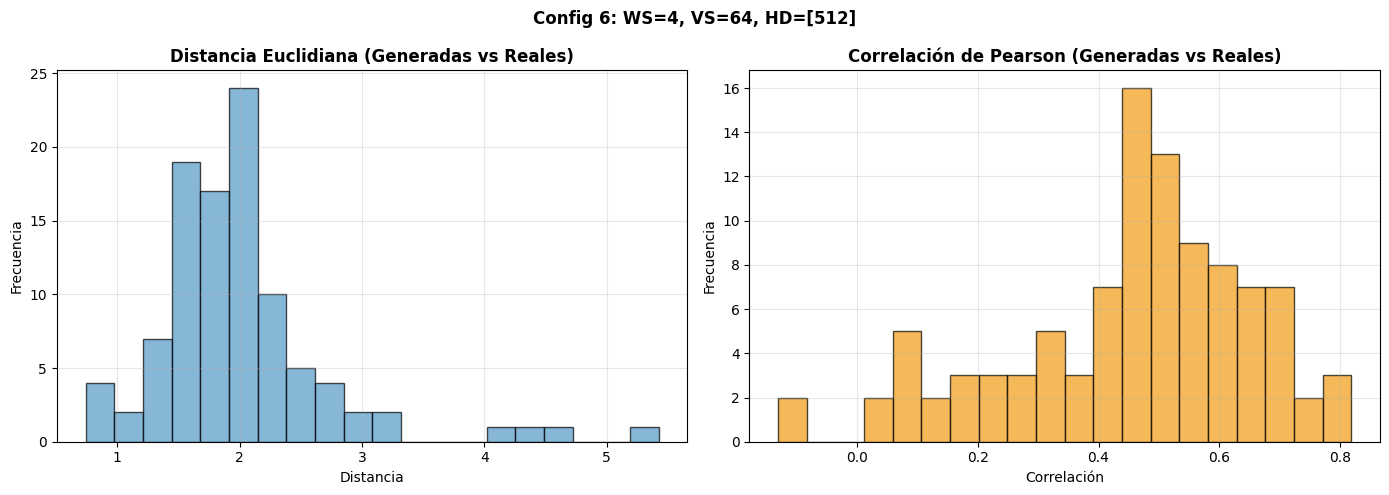


--------------------------------------------------------------------------------



In [14]:
def calculate_nll(model, dataset):
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    model.eval()
    total_nll = 0
    with torch.no_grad():
        for inputs in loader:
            inputs = inputs.to(device)
            logits = model(inputs)
            probs = torch.sigmoid(logits)
            epsilon = 1e-10
            batch_nll = - (inputs * torch.log(probs + epsilon) + (1 - inputs) * torch.log(1 - probs + epsilon)).sum(dim=1)
            total_nll += batch_nll.sum().item()
            
    return total_nll / len(dataset)

#Generar algunas mueestras y calcular el nll para todas las configuraciones 
for idx, result in enumerate(results):
    print(f"EVALUANDO CONFIGURACIÓN {idx+1}/6")
    print(f"WINDOW_SIZE: {result['WINDOW_SIZE']}, VOCAB_SIZE: {result['VOCAB_SIZE']}, HIDDEN_DIMS: {result['HIDDEN_DIMS']}")
    
    model = result['model']
    seq_len = result['seq_len']
    VOCAB_SIZE = result['VOCAB_SIZE']
    WINDOW_SIZE = result['WINDOW_SIZE']
    gmm = result['gmm']
    
    gen_signals = generate_samples(model, 5, seq_len, VOCAB_SIZE, WINDOW_SIZE, gmm)
    plt.figure(figsize=(12, 6))
    for i in range(5):
        plt.plot(gen_signals[i] + i*1.5, label=f'Generada {i}', linewidth=2)
    plt.title(f"Señales generadas - Config {idx+1}: WS={WINDOW_SIZE}, VS={VOCAB_SIZE}, HD={result['HIDDEN_DIMS']}", 
              fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    nll_train = calculate_nll(model, result['train_ds'])
    nll_val = calculate_nll(model, result['val_ds'])
    nll_test = calculate_nll(model, result['test_ds'])
    
    print(f"NLL promedio en Train: {nll_train:.4f}")
    print(f"NLL promedio en Val: {nll_val:.4f}")
    print(f"NLL promedio en Test: {nll_test:.4f}")
    
    result['nll_train'] = nll_train
    result['nll_val'] = nll_val
    result['nll_test'] = nll_test
    
    #Grafica de NLL en cada split
    nll_splits = {'Train': nll_train, 'Val': nll_val, 'Test': nll_test}
    labels_splits = list(nll_splits.keys())
    values_splits = list(nll_splits.values())
    colors_splits = ['#5499C7', '#AF7AC5', '#F39C12']
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(labels_splits, values_splits, color=colors_splits, edgecolor='black', linewidth=1.5)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f}',
                 ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    plt.title(f'NLL - Config {idx+1}: WS={WINDOW_SIZE}, VS={VOCAB_SIZE}, HD={result["HIDDEN_DIMS"]}', 
              fontsize=12, fontweight='bold')
    plt.ylabel('NLL Promedio', fontsize=12)
    plt.grid(axis='y', linestyle='-', alpha=0.3)
    plt.ylim(0, max(values_splits) * 1.15)
    plt.tight_layout()
    plt.show()
    
    X_anom = X[y != 'Normal']
    if len(X_anom) > 0:
        X_anom_sample = X_anom[:200]
        X_anom_padded = np.hstack((X_anom_sample, np.zeros((X_anom_sample.shape[0], 2))))
        X_anom_tokens = discretize_signals(X_anom_padded, WINDOW_SIZE, gmm)
        anom_ds = ECGTokenDataset(X_anom_tokens, VOCAB_SIZE)
        nll_anomaly = calculate_nll(model, anom_ds)
        print(f"NLL promedio en Anomalías: {nll_anomaly:.4f}")
        print(f"Diferencia: {nll_anomaly - nll_test:.4f}")
        result['nll_anomaly'] = nll_anomaly
    
    # Compare generated vs real
    print("\nComparación Generadas vs Reales")
    gen_samples_large = generate_samples(model, 100, seq_len, VOCAB_SIZE, WINDOW_SIZE, gmm)
    real_samples_reconstructed = reconstruct_signals(result['X_test'][:100], WINDOW_SIZE, gmm)
    
    from scipy.spatial.distance import euclidean
    from scipy.stats import pearsonr
    
    euclidean_dists = [euclidean(gen_samples_large[i], real_samples_reconstructed[i]) for i in range(100)]
    correlations = [pearsonr(gen_samples_large[i], real_samples_reconstructed[i])[0] for i in range(100)]
    
    print(f"Distancia Euclidiana promedio: {np.mean(euclidean_dists):.4f} ± {np.std(euclidean_dists):.4f}")
    print(f"Correlación de Pearson promedio: {np.mean(correlations):.4f} ± {np.std(correlations):.4f}")
    
    result['euclidean_mean'] = np.mean(euclidean_dists)
    result['correlation_mean'] = np.mean(correlations)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Config {idx+1}: WS={WINDOW_SIZE}, VS={VOCAB_SIZE}, HD={result["HIDDEN_DIMS"]}', 
                 fontsize=12, fontweight='bold')
    
    axes[0].hist(euclidean_dists, bins=20, color='#5499C7', edgecolor='black', alpha=0.7)
    axes[0].set_title('Distancia Euclidiana (Generadas vs Reales)', fontweight='bold')
    axes[0].set_xlabel('Distancia')
    axes[0].set_ylabel('Frecuencia')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].hist(correlations, bins=20, color='#F39C12', edgecolor='black', alpha=0.7)
    axes[1].set_title('Correlación de Pearson (Generadas vs Reales)', fontweight='bold')
    axes[1].set_xlabel('Correlación')
    axes[1].set_ylabel('Frecuencia')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    print("\n"+"-"*80+"\n")

In [17]:
print("RESUMEN DE TODAS LAS CONFIGURACIONES")

summary_data = []
for idx, result in enumerate(results):
    summary_data.append({
        'Config': f"{idx+1}",
        'WS': result['WINDOW_SIZE'],
        'VS': result['VOCAB_SIZE'],
        'HD': result['HIDDEN_DIMS'][0],
        'NLL_Train': result['nll_train'],
        'NLL_Val': result['nll_val'],
        'NLL_Test': result['nll_test'],
        'Euclidean': result['euclidean_mean'],
        'Correlation': result['correlation_mean']
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

RESUMEN DE TODAS LAS CONFIGURACIONES
Config  WS  VS  HD  NLL_Train   NLL_Val  NLL_Test  Euclidean  Correlation
     1   6 128 256  30.683547 35.395245 35.676221   2.245716     0.356959
     2   4 128 256  45.527317 55.175074 54.830729   2.185515     0.384906
     3   6  64 256  23.464433 27.042421 27.548680   1.908159     0.484812
     4   8 128 512  20.112118 24.252606 24.826372   2.075600     0.422905
     5   6 256 128  42.814785 45.928416 46.402676   2.250507     0.326231
     6   4  64 512  29.254162 40.503512 41.191074   1.998650     0.455739


ANÁLISIS DE ANOMALÍAS - CONFIGURACIÓN 1/6
WINDOW_SIZE: 6, VOCAB_SIZE: 128, HIDDEN_DIMS: [256]
 - ArrS: 53.9278
 - ArrV: 52.9223
 - ArrF: 34.2447
 - ArrV: 52.9223
 - ArrF: 34.2447
 - ArrQ: 57.7697
 - ArrQ: 57.7697


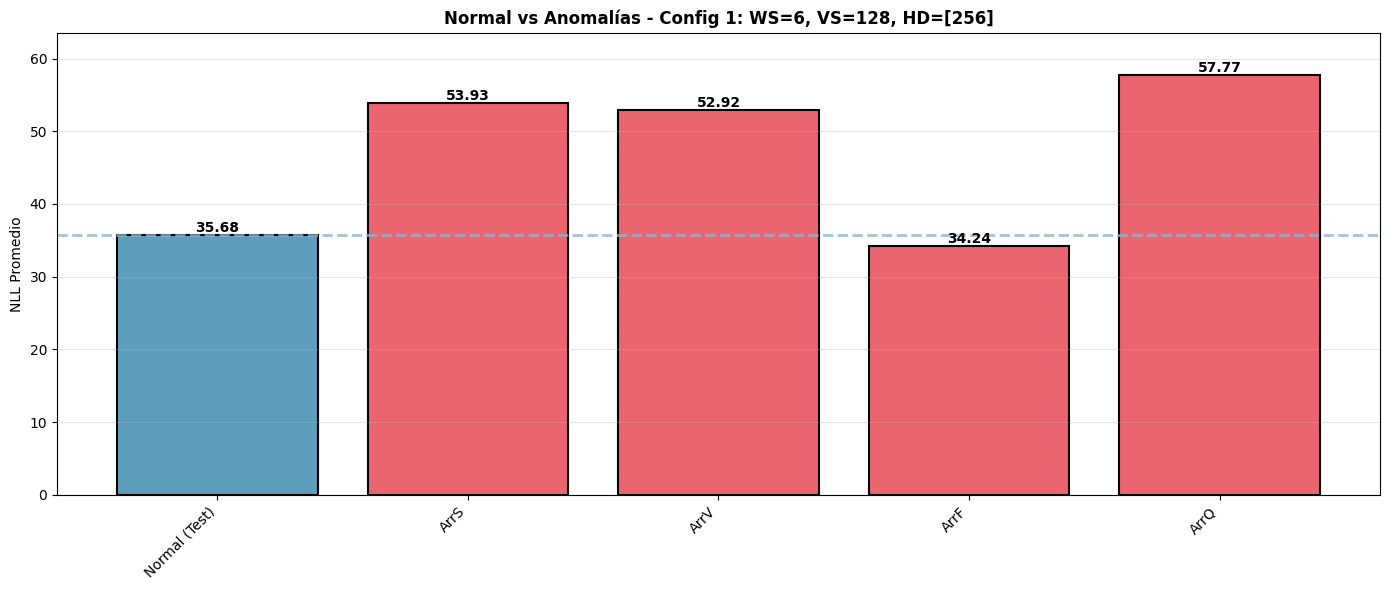

ANÁLISIS DE ANOMALÍAS - CONFIGURACIÓN 2/6
WINDOW_SIZE: 4, VOCAB_SIZE: 128, HIDDEN_DIMS: [256]
 - ArrS: 80.2392
 - ArrV: 84.1410
 - ArrF: 51.8849
 - ArrV: 84.1410
 - ArrF: 51.8849
 - ArrQ: 86.8204
 - ArrQ: 86.8204


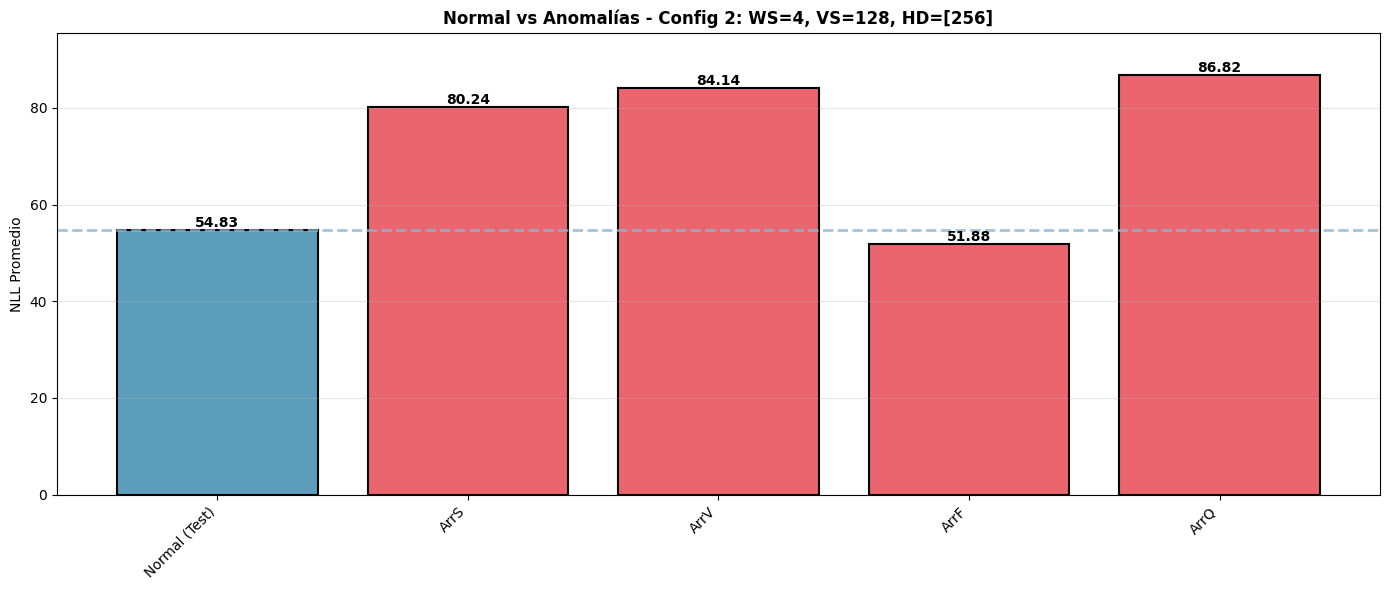

ANÁLISIS DE ANOMALÍAS - CONFIGURACIÓN 3/6
WINDOW_SIZE: 6, VOCAB_SIZE: 64, HIDDEN_DIMS: [256]
 - ArrS: 44.5051
 - ArrV: 45.1532
 - ArrF: 27.1297
 - ArrQ: 46.3218
 - ArrV: 45.1532
 - ArrF: 27.1297
 - ArrQ: 46.3218


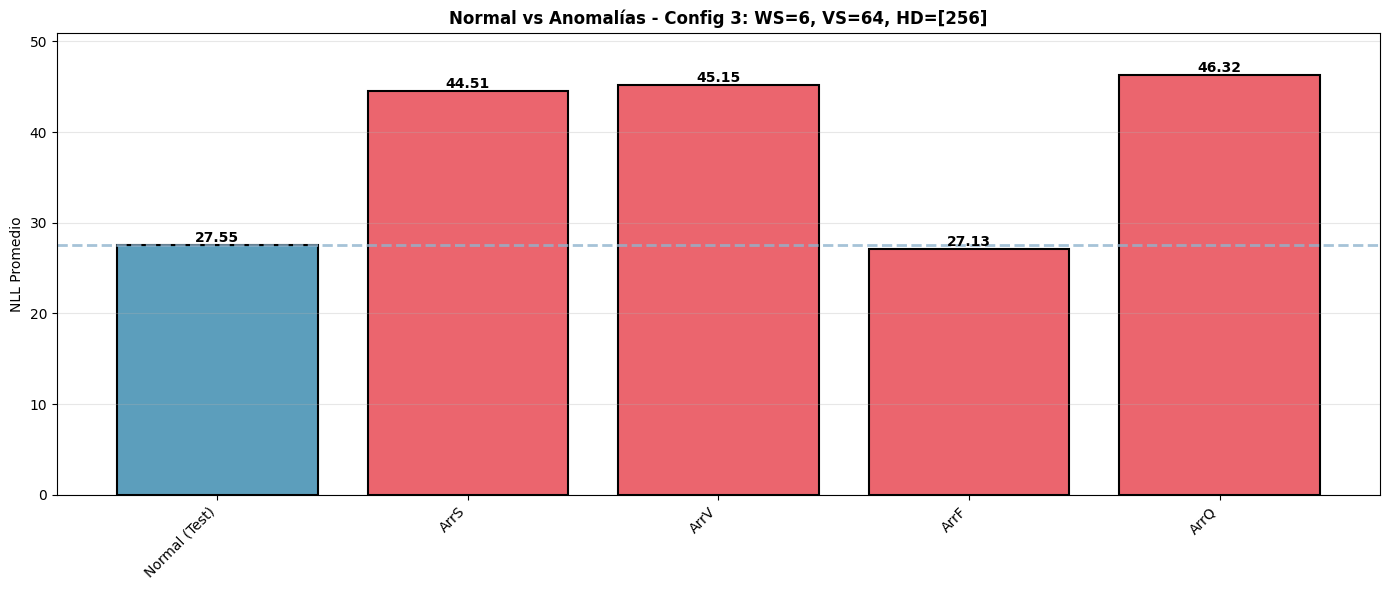

ANÁLISIS DE ANOMALÍAS - CONFIGURACIÓN 4/6
WINDOW_SIZE: 8, VOCAB_SIZE: 128, HIDDEN_DIMS: [512]
 - ArrS: 41.7064
 - ArrV: 42.8856
 - ArrF: 24.2453
 - ArrV: 42.8856
 - ArrF: 24.2453
 - ArrQ: 44.3866
 - ArrQ: 44.3866


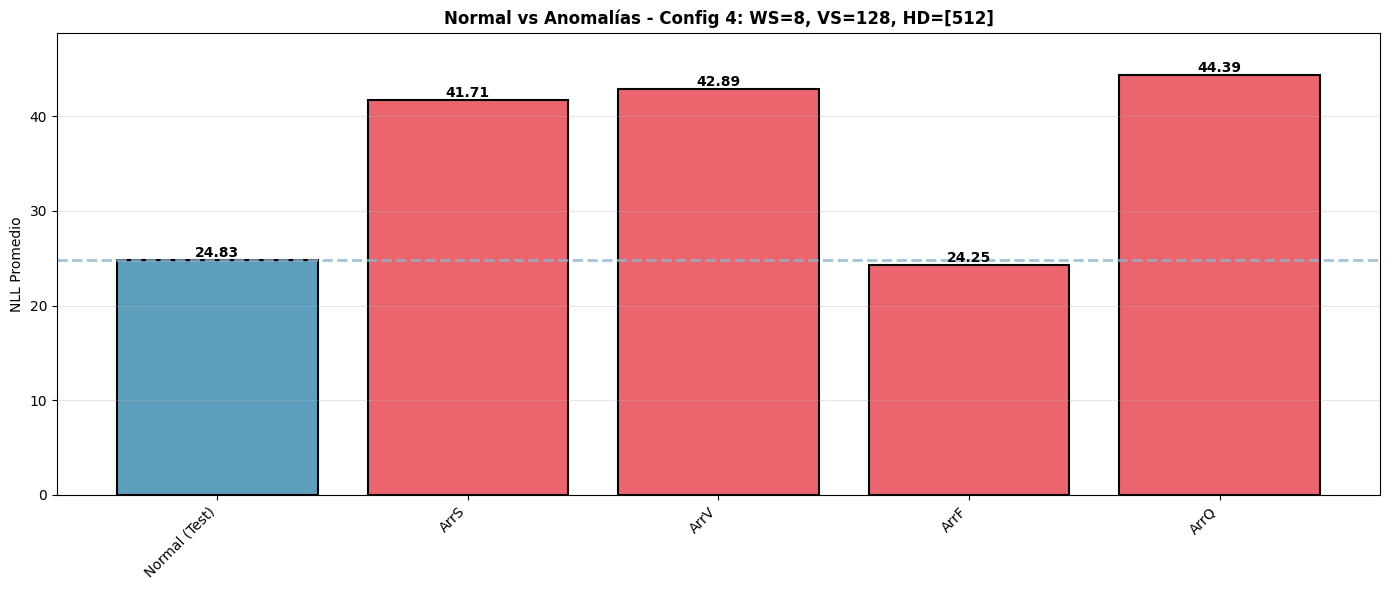

ANÁLISIS DE ANOMALÍAS - CONFIGURACIÓN 5/6
WINDOW_SIZE: 6, VOCAB_SIZE: 256, HIDDEN_DIMS: [128]
 - ArrS: 63.9327
 - ArrV: 63.9064
 - ArrF: 42.2234
 - ArrV: 63.9064
 - ArrF: 42.2234
 - ArrQ: 67.1363
 - ArrQ: 67.1363


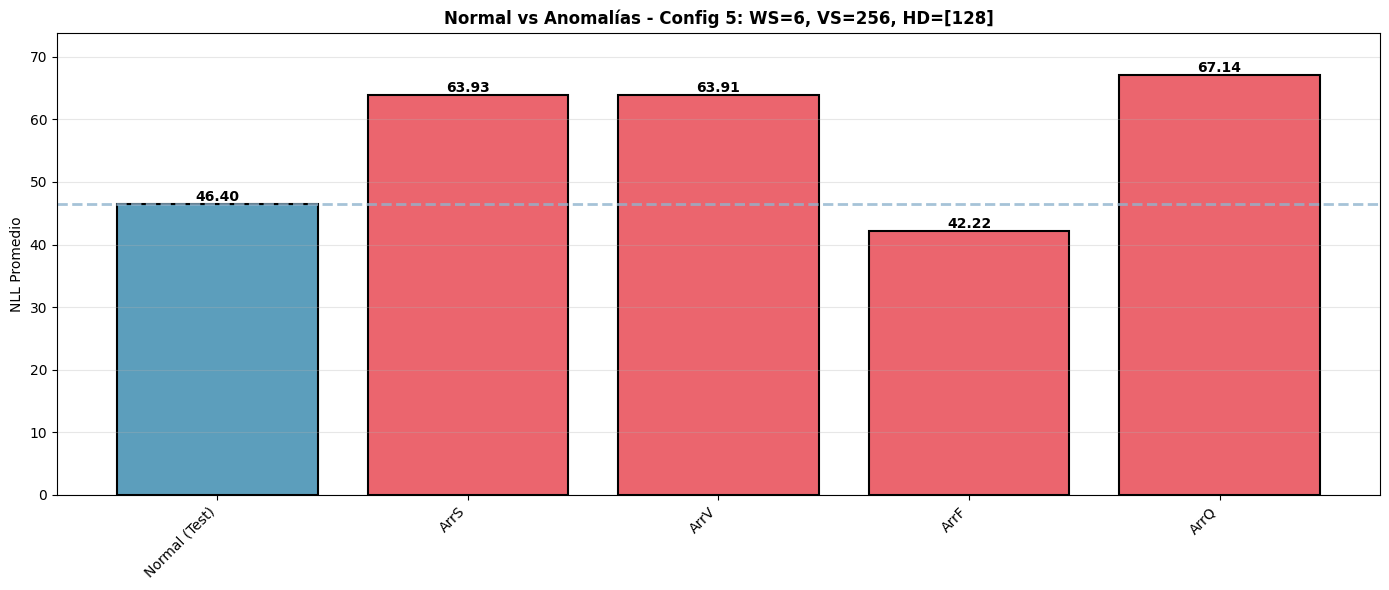

ANÁLISIS DE ANOMALÍAS - CONFIGURACIÓN 6/6
WINDOW_SIZE: 4, VOCAB_SIZE: 64, HIDDEN_DIMS: [512]
 - ArrS: 66.9946
 - ArrV: 73.6036
 - ArrF: 39.9347
 - ArrV: 73.6036
 - ArrF: 39.9347
 - ArrQ: 77.3476
 - ArrQ: 77.3476


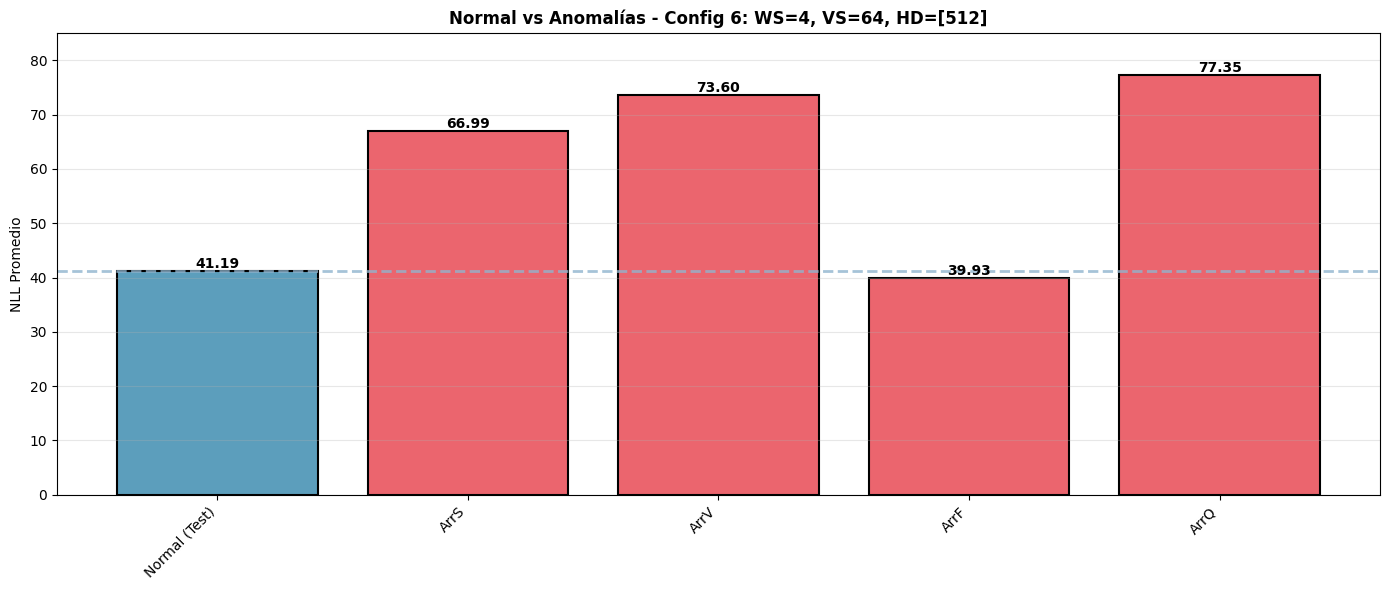

In [21]:
#Detección de anomalias 
class_map = {1: 'ArrS', 2: 'ArrV', 3: 'ArrF', 4: 'ArrQ'}

for idx, result in enumerate(results):
    print(f"ANÁLISIS DE ANOMALÍAS - CONFIGURACIÓN {idx+1}/6")
    print(f"WINDOW_SIZE: {result['WINDOW_SIZE']}, VOCAB_SIZE: {result['VOCAB_SIZE']}, HIDDEN_DIMS: {result['HIDDEN_DIMS']}")
    
    model = result['model']
    WINDOW_SIZE = result['WINDOW_SIZE']
    VOCAB_SIZE = result['VOCAB_SIZE']
    gmm = result['gmm']
    nll_test = result['nll_test']
    
    nll_results = {'Normal (Test)': nll_test}
    
    for class_id, class_name in class_map.items():
        X_class = X[y == class_name]
        
        if len(X_class) == 0:
            continue
            
        limit = min(len(X_class), 500)
        X_class_sample = X_class[:limit]
        
        padding = np.zeros((X_class_sample.shape[0], 2))
        X_class_padded = np.hstack((X_class_sample, padding))
        X_class_tokens = discretize_signals(X_class_padded, WINDOW_SIZE, gmm)
        ds_class = ECGTokenDataset(X_class_tokens, VOCAB_SIZE)
        nll_val = calculate_nll(model, ds_class)
        nll_results[class_name] = nll_val
        print(f" - {class_name}: {nll_val:.4f}")
    
    labels = list(nll_results.keys())
    values = list(nll_results.values())
    colors = ['#5c9ebc' if 'Normal' in label else '#eb656e' for label in labels]
    
    plt.figure(figsize=(14, 6))
    bars = plt.bar(labels, values, color=colors, edgecolor='black', linewidth=1.5)
    plt.axhline(y=nll_results['Normal (Test)'], color='#90b4ce', linestyle='--', linewidth=2, alpha=0.8)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f}',
                 ha='center', va='bottom', fontweight='bold')
    
    plt.title(f'Normal vs Anomalías - Config {idx+1}: WS={WINDOW_SIZE}, VS={VOCAB_SIZE}, HD={result["HIDDEN_DIMS"]}', 
              fontsize=12, fontweight='bold')
    plt.ylabel('NLL Promedio')
    plt.grid(axis='y', linestyle='-', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, max(values) * 1.1)
    plt.tight_layout()
    plt.show()
